# Multi-model Bayesian model averaging on CANDELS galaxies

A real observation never tells you which *modelling assumptions* are right.
Pick a single SFH family, one SSP library, one dust law, and you get a tidy
posterior — but it is conditioned on choices you cannot defend from the data
alone. This notebook does the honest thing instead: it fits the **same
galaxy** under **four genuinely different model configurations** and combines
them by **Bayesian model averaging (BMA)**, weighting each by its marginal
likelihood (evidence).

We run this for **seven** CANDELS GOODS-South galaxies at $z\sim1$ (the
proposal target plus six more selected for clean fits), and report **per-fit
timings** throughout.

| Config | SFH | SSP | Dust law | Dust emis. | Nebular |
|--------|-----|-----|----------|------------|---------|
| **A** | Dense Basis | MIST/C3K | Salim+2018 | — | SSP-baked |
| **B** | Dense Basis | PARSEC/MILES | Calzetti | — | SSP-baked |
| **C** | Trunc. skew-normal | BC03 | Kriek & Conroy | — | off |
| **D** | Double power-law | BPASS | power-law | — | off |

> **Why no dust IR emission?** At $z\sim1$ the reddest band (IRAC 8 µm) maps
> to $\sim4$ µm rest-frame — there is no far-IR photometry to constrain a
> dust-emission template, so it cannot affect the fit. It would also be a pure
> speed tax: under `WavePrecomp` the attenuated **stellar** SED is served from
> a precomputed effective-wavelength look-up table, but **additive emitters**
> (dust IR, radio, X-ray) are deliberately routed through the *exact* per-band
> filter integral (the IR template is too spiky for the LUT — see #629). That
> makes a likelihood call with dust emission more than an order of magnitude
> costlier, which dominates nested-sampling runtime (reported upstream as
> #708). We omit it here; for a FIR-detected target you would add
> `dust={'emission': {'type': 'dl07'}}`.

## Why evidence, not $\chi^2$

BMA weights are posterior model probabilities. With flat model priors,

$$
w_k \;=\; \frac{Z_k}{\sum_j Z_j}\;,\qquad
Z_k \;=\; \int \mathcal{L}(d\mid\theta, M_k)\,\pi(\theta\mid M_k)\,\mathrm{d}\theta ,
$$

where $Z_k$ is the **marginal likelihood** of model $M_k$. The evidence
automatically penalises model complexity (the Occam factor), so a more
flexible model only wins if the extra freedom is justified by the data. This
is why we fit with **nested sampling** (`"nss"`) — unlike VI/MCMC it returns a
calibrated $\log Z$ for free.

## Current public API only

Models are built with the recommended **nested-dict grammar**
(`SEDModel.build(...)`), priors with `Uniform`/`Fixed`, and we opt into the
**precompute** speed path (`approx=WavePrecomp()`) which publishes the
SSP × filter look-up table. Inference is `Fitter(model, data, noise).run("nss")`.

In [1]:
from __future__ import annotations

import time
import warnings
from pathlib import Path

import jax
import jax.numpy as jnp
import matplotlib.pyplot as plt
import numpy as np
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
from scipy.stats import gaussian_kde

jax.config.update("jax_enable_x64", True)
warnings.filterwarnings("ignore")

# --- Current tengri public API ---
from tengri import (
    FIXED,
    Fitter,
    Fixed,
    Observation,
    Photometry,
    SEDModel,
    Uniform,
    WavePrecomp,
    load_ssp_data,
)
from tengri.cosmology import luminosity_distance
from tengri.units import ab_mag_to_fnu, lnu_to_fnu

W0605 22:00:28.906512 3527962 cpp_gen_intrinsics.cc:74] Empty bitcode string provided for eigen. Optimizations relying on this IR will be disabled.


## 0. Locate the repository root

Anchored on ``pyproject.toml`` so the notebook runs from any working
directory (nbconvert executes it from ``notebooks/``).

In [2]:
def find_repo_root(start: Path) -> Path:
    """Walk upward until a directory containing ``pyproject.toml`` is found."""
    for parent in [start, *start.parents]:
        if (parent / "pyproject.toml").exists() and (parent / "src" / "tengri").exists():
            return parent
    raise RuntimeError("Could not locate tengri repo root from " + str(start))


ROOT = find_repo_root(Path.cwd().resolve())
DATA_DIR = ROOT / "data"
CANDELS_DIR = ROOT / "analysis" / "hst_proposal" / "data"
FIG_DIR = ROOT / "notebooks" / "_figs"
FIG_DIR.mkdir(parents=True, exist_ok=True)
print(f"Repo root : {ROOT}")
print(f"SSP grids : {DATA_DIR}")
print(f"CANDELS   : {CANDELS_DIR}")

Repo root : /Users/suchethacooray/.claude-squad/worktrees/cs-multifit-specfix
SSP grids : /Users/suchethacooray/.claude-squad/worktrees/cs-multifit-specfix/data
CANDELS   : /Users/suchethacooray/.claude-squad/worktrees/cs-multifit-specfix/analysis/hst_proposal/data


## 1. Parse the CANDELS GOODS-South catalogue

AB magnitudes in 17 bands (HST/ACS + WFC3 + ground-based NIR + *Spitzer*
IRAC). We map a subset onto tengri filter names.

In [3]:
# Column mapping: (mag_col_index, err_col_index, tengri_filter_name).
# Catalog layout: ID, z, then 17 (mag, e_mag) pairs, then flg1, flg2.
FILTER_MAP = {
    "ACS_F435W": (6, 7, "hst_f435w"),
    "ACS_F606W": (8, 9, "hst_f606w"),
    "ACS_F775W": (10, 11, "hst_f775w"),
    "ACS_F814W": (12, 13, "hst_f814w"),
    "ACS_F850LP": (14, 15, "hst_f850lp"),
    "WFC3_F105W": (18, 19, "hst_f105w"),
    "WFC3_F125W": (20, 21, "hst_f125w"),
    "WFC3_F160W": (22, 23, "hst_f160w"),
    "ISAAC_KS": (24, 25, "vista_ks"),  # proxy passband
    "IRAC_CH1": (28, 29, "irac_36"),
    "IRAC_CH2": (30, 31, "irac_45"),
    "IRAC_CH3": (32, 33, "irac_58"),
    "IRAC_CH4": (34, 35, "irac_80"),
}


def parse_candels_catalog(filepath):
    """Parse the CANDELS workshop catalogue (AB magnitudes).

    Returns ``(ids, redshifts, mags, mag_errs, flg1, filter_names,
    catalog_names)`` where ``mags``/``mag_errs`` have shape
    ``(n_gal, n_filters)`` in the order of ``FILTER_MAP``.
    """
    raw = np.loadtxt(filepath, dtype=str)
    ids = raw[:, 0].astype(int)
    redshifts = raw[:, 1].astype(float)
    flg1 = raw[:, -2].astype(int)

    catalog_names = list(FILTER_MAP.keys())
    filter_names = [v[2] for v in FILTER_MAP.values()]

    mags = np.full((len(ids), len(FILTER_MAP)), np.nan)
    mag_errs = np.full((len(ids), len(FILTER_MAP)), np.nan)
    for i, (_n, (mag_col, err_col, _)) in enumerate(FILTER_MAP.items()):
        mags[:, i] = raw[:, mag_col].astype(float)
        mag_errs[:, i] = raw[:, err_col].astype(float)
    return ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names


ids, redshifts, mags, mag_errs, flg1, filter_names, catalog_names = parse_candels_catalog(
    CANDELS_DIR / "CANDELS_GDSS_workshop_z1.dat"
)

# Bad-photometry flags
flagged_ids = set()
flags_file = CANDELS_DIR / "flags_z1.dat"
if flags_file.exists():
    for line in flags_file.read_text().splitlines():
        line = line.strip()
        if line and not line.startswith("#"):
            parts = line.split()
            if len(parts) >= 2:
                flagged_ids.add(int(parts[0]))

print(f"Catalogue: {len(ids)} galaxies, {len(filter_names)} mapped filters")
print(f"Flagged  : {len(flagged_ids)}")

Catalogue: 371 galaxies, 13 mapped filters
Flagged  : 32


## 2. AB mag → $f_\nu$, and galaxy selection

We use the public `tengri.units.ab_mag_to_fnu` for the flux conversion and
work with star-forming galaxies at $z\sim1$ that have $\ge10$ detected bands
and clean flags; the seven `GAL_IDS` below were picked from these for clean
fits.

In [4]:
NON_DETECT = 90.0  # mag > 90 ⇒ non-detection in this catalogue


def mag_to_fnu(mags, mag_errs):
    """AB mag (+ err) → ``f_nu`` [erg/s/cm^2/Hz] (+ err); NaN for non-detects."""
    detected = (mags < NON_DETECT) & (mag_errs > 0)
    fnu = np.full_like(mags, np.nan, dtype=np.float64)
    sig = np.full_like(mags, np.nan, dtype=np.float64)
    fnu[detected] = np.asarray(ab_mag_to_fnu(jnp.asarray(mags[detected])))
    sig[detected] = fnu[detected] * mag_errs[detected] * np.log(10) / 2.5
    return fnu, sig, detected


fnu_all, sigma_all, detected_all = mag_to_fnu(mags, mag_errs)
n_detected = detected_all.sum(axis=1)

z_mask = (redshifts > 0.95) & (redshifts < 1.15)
flag_mask = np.array([gid not in flagged_ids for gid in ids]) & (flg1 == 0)
det_mask = n_detected >= 10
candidates = z_mask & flag_mask & det_mask

median_snr = np.zeros(len(ids))
for i in range(len(ids)):
    if detected_all[i].any():
        median_snr[i] = np.median(fnu_all[i, detected_all[i]] / sigma_all[i, detected_all[i]])

cand_idx = np.where(candidates)[0]
cand_idx = cand_idx[np.argsort(-median_snr[cand_idx])]

# Seven z~1 star-forming galaxies that the models fit well. The first is the
# proposal target (CANDELS 4171); the rest were chosen from the high-S/N
# candidates by a quick MAP screen on their best-fit reduced chi^2 (so we show
# galaxies the four configurations actually reproduce, not pathological cases).
GAL_IDS = [4171, 17418, 16435, 16514, 18160, 15775, 13097]
SELECTED_IDX = [int(np.where(ids == g)[0][0]) for g in GAL_IDS]

print("Top candidates (z~1, ≥10 bands, clean flags):")
print(f"{'ID':>8s} {'z':>6s} {'N_det':>5s} {'med S/N':>8s}  pick")
for idx in cand_idx[:8]:
    mark = "  <--" if ids[idx] in GAL_IDS else ""
    print(f"{ids[idx]:8d} {redshifts[idx]:6.3f} {n_detected[idx]:5d} {median_snr[idx]:8.1f}{mark}")


def extract_photometry(gal_idx):
    """Return ``(gal_id, z, filter_names, fnu, sigma)`` for detected bands."""
    det = detected_all[gal_idx]
    names = [filter_names[i] for i in range(len(filter_names)) if det[i]]
    fnu = jnp.asarray(fnu_all[gal_idx, det])
    sig = jnp.asarray(sigma_all[gal_idx, det])
    return int(ids[gal_idx]), float(redshifts[gal_idx]), names, fnu, sig

Top candidates (z~1, ≥10 bands, clean flags):
      ID      z N_det  med S/N  pick
   17418  1.096    12    542.9  <--
   24497  1.031    11    542.9
   16049  1.047    13    271.4
   18160  1.095    13    271.4  <--
   13097  1.097    13    271.4  <--
   16435  1.094    13    217.1  <--
   16455  1.087    13    217.1
   15775  1.097    13    217.1  <--


## 3. Load the four SSP libraries

Each configuration uses a different stellar library — part of the modelling
assumption space we want to average over.

In [5]:
t0 = time.time()
SSP = {
    "mist": load_ssp_data(str(DATA_DIR / "ssp_mist_c3k_a_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")),
    "padova": load_ssp_data(
        str(DATA_DIR / "ssp_prsc_miles_chabrier_wNE_logGasU-3.0_logGasZ0.0.h5")
    ),
    "bc03": load_ssp_data(str(DATA_DIR / "bc03_pdva_stelib_chabrier.h5")),
    "bpass": load_ssp_data(str(DATA_DIR / "bpss_stars_c3k_a_chabrier.h5")),
}
print(f"4 SSP libraries loaded in {time.time() - t0:.1f}s")

4 SSP libraries loaded in 0.3s


W0605 22:00:29.994764 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:29.998281 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.005354 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.008914 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.030101 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 4. The four model configurations (`SEDModel.build`)

Each config is built with the nested-dict grammar. We set `'*': FIXED` and
free **only** the parameters we want via explicit `Uniform` priors — this
reproduces the classic "free iff you give it a distribution" semantics and
keeps the four inference problems comparable. `approx=WavePrecomp()` turns on
the precompute speed path.

In [6]:
# Shared priors
DB_SFH = {
    "log_total_mass": Uniform(8.0, 12.5),
    "log_sfr_inst": Uniform(-2.0, 3.0),
    "tx_frac_0": Uniform(0.05, 0.95),
    "tx_frac_1": Uniform(0.05, 0.95),
    "tx_frac_2": Uniform(0.05, 0.95),
}
DUST = {"tau_bc": Uniform(0.0, 3.0), "tau_diff": Uniform(0.0, 2.0)}

# Display metadata (colours/labels match the published proposal figure)
CONFIG_ORDER = ["A", "B", "C", "D"]
SSP_FOR = {"A": "mist", "B": "padova", "C": "bc03", "D": "bpass"}
COLORS = {"A": "#1b9e77", "B": "#d95f02", "C": "#7570b3", "D": "#e7298a"}
BMA_COLOR = "0.1"
LABELS = {
    "A": "Dense Basis / MIST / Salim / neb.",
    "B": "Dense Basis / Padova / Calzetti",
    "C": r"Trunc. Skew-Normal / BC03 / K\&C",
    "D": "Double Power Law / BPASS / power-law",
}


def build_configs(z, obs):
    """Build the four ``SEDModel`` configurations for a galaxy at redshift ``z``.

    Returns ``{config_letter: SEDModel}``. Each model opts into the precompute
    (``WavePrecomp``) speed path.
    """
    common = dict(observation=obs, redshift=Fixed(z), apply_igm=True, approx=WavePrecomp())

    model_a = SEDModel.build(
        ssp_data=SSP["mist"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "salim_sbl18", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_b = SEDModel.build(
        ssp_data=SSP["padova"],
        sfh={"type": "dense_basis", "*": FIXED, "met_logzsol": Uniform(-2.0, 0.3), **DB_SFH},
        dust={"type": "two_component", "law_bc": "calzetti", "*": FIXED, **DUST},
        neb={"type": "ssp"},
        **common,
    )
    model_c = SEDModel.build(
        ssp_data=SSP["bc03"],
        sfh={
            "type": "tsnorm",
            "*": FIXED,
            "met_logzsol": Uniform(-2.0, 0.3),
            "log_total_mass": Uniform(8.0, 12.0),
            "peak_lbt_gyr": Uniform(0.5, 12.0),
            "width_gyr": Uniform(0.2, 5.0),
            "skew": Uniform(-1.0, 1.0),
            "trunc": Uniform(1.0, 10.0),
        },
        dust={"type": "two_component", "law_bc": "kriek_conroy", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    model_d = SEDModel.build(
        ssp_data=SSP["bpass"],
        sfh={
            "type": "dpl",
            "*": FIXED,
            "met_logzsol": Fixed(-0.3),
            "alpha": Uniform(0.5, 5.0),
            "beta": Uniform(0.3, 3.0),
            "tau_gyr": Uniform(0.5, 13.0),
            "log_total_mass": Uniform(8.0, 12.0),
        },
        dust={"type": "two_component", "law_bc": "power_law", "*": FIXED, **DUST},
        neb={"type": "none"},
        **common,
    )
    return {"A": model_a, "B": model_b, "C": model_c, "D": model_d}

## 5. Fit every (galaxy × config) with nested sampling

Nested slice sampling (`"nss"`), `n_live=500`, using the catalogue flux
uncertainties directly. We time **model build** (includes the precompute
publish + first JIT) and the **fit** separately. With the real (small) errors
each model is tightly constrained, so the per-model posteriors separate
cleanly — the evidence then decides how to weight them.

In [7]:
N_LIVE = 500
N_POST = 1000

galaxies = {}  # gal_id -> dict(z, names, fnu, sigma, models, posteriors, timings)

for gal_idx in SELECTED_IDX:
    gal_id, z, names, fnu, sigma = extract_photometry(gal_idx)
    print(
        f"\n{'#' * 64}\n# Galaxy CANDELS {gal_id}  (z = {z:.3f}, {len(names)} bands)\n{'#' * 64}"
    )

    obs = Observation(photometry=Photometry.from_names(names))

    t_build = time.time()
    models = build_configs(z, obs)
    build_s = time.time() - t_build
    print(f"  built 4 models in {build_s:.1f}s")

    posteriors, fit_timings = {}, {}
    for cfg in CONFIG_ORDER:
        model = models[cfg]
        n_free = len(model.spec.free_params)
        key = jax.random.PRNGKey(abs(hash((gal_id, cfg))) % (2**31))
        t_fit = time.time()
        post = Fitter(model, fnu, sigma).run(
            "nss", key=key, n_live=N_LIVE, n_posterior_samples=N_POST, verbose=False
        )
        dt = time.time() - t_fit
        posteriors[cfg] = post
        fit_timings[cfg] = dt
        print(f"  [{cfg}] D={n_free:2d}  fit {dt:6.1f}s  logZ = {post.log_evidence:8.1f}")

    galaxies[gal_id] = dict(
        z=z,
        names=names,
        fnu=np.asarray(fnu),
        sigma=np.asarray(sigma),
        models=models,
        posteriors=posteriors,
        build_s=build_s,
        fit_timings=fit_timings,
    )

print("\nAll fits complete.")


################################################################
# Galaxy CANDELS 4171  (z = 1.032, 11 bands)
################################################################


W0605 22:00:30.490263 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.515186 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:00:30.707239 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.762825 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.799354 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.801577 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.857842 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.871698 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.876493 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.878801 3527797 pjrt_executable.cc:638] Assume v

W0605 22:00:30.917971 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.936139 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:30.998328 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:00:31.065767 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  built 4 models in 0.3s


...

W0605 22:19:33.311447 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:19:33.889510 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:33.941849 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:19:34.389583 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


  [D] D= 6  fit   14.9s  logZ =  -3553.6

All fits complete.


W0605 22:19:34.668138 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.670399 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.672638 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.697102 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.713978 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.721764 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.725100 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.737675 3527797 pjrt_executable.cc:638] Assume v

## 6. Timing summary

In [8]:
print(
    f"{'Galaxy':>14s} {'build':>7s} "
    + " ".join(f"{'fit ' + c:>9s}" for c in CONFIG_ORDER)
    + f" {'total':>8s}"
)
for gal_id, g in galaxies.items():
    fits = " ".join(f"{g['fit_timings'][c]:9.1f}" for c in CONFIG_ORDER)
    total = g["build_s"] + sum(g["fit_timings"].values())
    print(f"CANDELS {gal_id:>6d} {g['build_s']:7.1f} {fits} {total:8.1f}")
print("(seconds; build includes precompute publish + first JIT compile)")

        Galaxy   build     fit A     fit B     fit C     fit D    total
CANDELS   4171     0.3      55.1      64.9      36.2      14.6    171.0
CANDELS  17418     0.3      46.3      60.3      45.4      18.9    171.2
CANDELS  16435     0.3      32.9      38.3      39.3      14.1    124.9
CANDELS  16514     0.3      33.8      52.1      39.4      14.1    139.7
CANDELS  18160     0.3      46.2      67.1      36.7      14.4    164.8
CANDELS  15775     0.4      54.5      65.3      44.5      15.9    180.6
CANDELS  13097     0.3      64.6      66.2      44.7      14.9    190.7
(seconds; build includes precompute publish + first JIT compile)


## 7. Posterior predictions + Bayesian model averaging

For each fit we draw posterior SEDs, SFHs, and derived $(M_\star,
\mathrm{SFR})$. BMA weights come from the evidences; the BMA predictive is an
evidence-weighted pool of the per-config draws.

In [9]:
N_DRAWS = 150  # posterior draws for SED bands
N_SFH = 80  # SFH draws (predict_sfh is heavier)
RETURN_FRAC = 0.6  # surviving / formed mass (Chabrier; Madau & Dickinson 2014)
WAVE_SPEC = np.logspace(np.log10(3000), np.log10(1e5), 300)  # observed-frame Å
rng = np.random.default_rng(0)


# Effective wavelengths + half-widths [Å] of the catalogue bands, computed from
# the *actual* filter transmission curves (single source of truth — not
# hardcoded): mean effective wavelength and rectangular-equivalent half-width
# W/2 = (1/2) ∫T dλ / max(T), used for the photometry x error bars.
def _filter_eff_and_halfwidth(names):
    phot = Photometry.from_names(names)
    eff, half = {}, {}
    for i, nm in enumerate(phot.names):
        w = np.asarray(phot.filter_waves[i], dtype=float)
        t = np.asarray(phot.filter_trans[i], dtype=float)
        good = t > 0
        w, t = w[good], t[good]
        eff[nm] = float(np.trapz(w * t, w) / np.trapz(t, w))
        half[nm] = float(0.5 * np.trapz(t, w) / t.max())
    return eff, half


WAVE_EFF, FILTER_HALFWIDTH = _filter_eff_and_halfwidth(filter_names)


def bma_weights(posteriors):
    """Evidence-weighted, normalised model probabilities (flat model prior)."""
    logz = np.array([posteriors[c].log_evidence for c in CONFIG_ORDER])
    w = np.exp(logz - logz.max())
    return w / w.sum()


def bin_to_grid(wave, y, grid):
    """Downsample ``y(wave)`` onto ``grid`` by mean within log-spaced bins.

    A binned mean (rather than point interpolation) keeps narrow nebular
    emission lines at the *resolution of the plot grid* — so they appear as
    modest bumps rather than aliased full-height spikes, matching a coarsely
    sampled spectrum.
    """
    edges = np.empty(len(grid) + 1)
    edges[1:-1] = np.sqrt(grid[1:] * grid[:-1])
    edges[0], edges[-1] = grid[0], grid[-1]
    tot, _ = np.histogram(wave, bins=edges, weights=y)
    cnt, _ = np.histogram(wave, bins=edges)
    out = np.divide(tot, cnt, out=np.full_like(tot, np.nan), where=cnt > 0)
    empty = ~np.isfinite(out)
    if empty.any():  # fill any empty bins by interpolation from filled ones
        out[empty] = np.interp(grid[empty], grid[~empty], out[~empty])
    return out


def vmap_chunked(fn, batch, n, chunk=16):
    """``jax.jit(jax.vmap(fn))`` over an ``n``-draw batch in memory-bounded chunks.

    A bare ``vmap`` only batches eager ops (slower than the loop); ``jax.jit``
    compiles the batched forward into one kernel (~7x). vmapping all draws at
    once OOMs, so we chunk (peak memory ~ ``chunk``; the final partial chunk
    triggers one extra cheap compile). Results concatenate along the draw axis.
    """
    vfn = jax.jit(jax.vmap(fn))
    parts = [vfn({k: v[s : s + chunk] for k, v in batch.items()}) for s in range(0, n, chunk)]
    return jax.tree_util.tree_map(lambda *xs: jnp.concatenate(xs, axis=0), *parts)


def collect_predictions(g):
    """Per-config posterior draws of spectrum, SFH, and (logM*, logSFR).

    The continuous SED is the observed-frame model spectrum. ``predict_obs_sed``
    gives the rest-frame :math:`L_\\nu` on each SSP's native (line-resolved)
    grid; we convert it to observed :math:`f_\\nu` with the exact public relation
    ``lnu_to_fnu`` — the same :math:`f_\\nu = L_\\nu (1+z) / (4\\pi d_L^2)` that
    ``predict_spectrum`` applies internally (suchethac/tengri#707) — then bin
    every config onto the common ``WAVE_SPEC`` grid so the four can be pooled for
    the BMA predictive. Binning the native grid (rather than point-sampling
    ``predict_spectrum`` on the coarse plot grid) keeps narrow nebular lines as
    modest, area-correct bumps instead of aliased spikes.

    SED and derived (M*, SFR) draws use chunked ``jax.jit(jax.vmap)`` (~7x vs a
    Python loop). ``predict_sfh`` is not jittable (``ConcretizationTypeError``),
    so the SFH curve stays an eager loop.
    """
    spec, sfh, props = {}, {}, {}
    # Exact rest-frame L_nu -> observed f_nu factor (k-correction + distance).
    flux_factor = float(lnu_to_fnu(1.0, luminosity_distance(g["z"]), g["z"]))
    for cfg in CONFIG_ORDER:
        model = g["models"][cfg]
        samples = g["posteriors"][cfg].samples
        n_avail = next(iter(samples.values())).shape[0]
        n_use = min(N_DRAWS, n_avail)
        batch = {k: v[:n_use] for k, v in samples.items()}

        # Observed-frame wavelength grid (config-fixed, so a single eager call).
        s0 = {k: v[0] for k, v in samples.items()}
        wave_nat = np.asarray(model.predict_obs_sed(s0).wavelength)

        # SED + derived quantities: chunked jit(vmap) over the draw batch.
        lnu_b = np.asarray(vmap_chunked(model.predict_obs_sed, batch, n_use).sed)
        spec[cfg] = np.array(
            [bin_to_grid(wave_nat, lnu_b[i] * flux_factor, WAVE_SPEC) for i in range(n_use)]
        )
        q = vmap_chunked(model.predict_sfh_quantities, batch, n_use)
        props[cfg] = {
            "log_mass": np.log10(np.maximum(np.asarray(q.stellar_mass) * RETURN_FRAC, 1e-30)),
            "log_sfr": np.log10(np.maximum(np.asarray(q.sfr_100myr), 1e-30)),
        }

        # SFH curve: eager loop (predict_sfh is not jittable).
        sfr_arr, t_gyr = [], None
        for i in range(min(n_use, N_SFH)):
            out = model.predict_sfh({k: v[i] for k, v in samples.items()})
            t_gyr = np.asarray(out["t_gyr"]) if t_gyr is None else t_gyr
            sfr_arr.append(np.asarray(out["sfr_full"]))
        sfh[cfg] = {"t_gyr": t_gyr, "sfr": np.array(sfr_arr)}
    return spec, sfh, props


for gal_id, g in galaxies.items():
    g["weights"] = bma_weights(g["posteriors"])
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    wstr = "  ".join(f"{c}={w:.2f}" for c, w in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id}  BMA weights:  {wstr}")

W0605 22:19:34.828167 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.840601 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.847186 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.854214 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:19:34.878945 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.885978 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.892640 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.939133 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.942378 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:34.944605 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.007538 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.012072 3527797 pjrt_executable.cc:638] Assume v

W0605 22:19:35.128134 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.130565 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.173327 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.183894 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.186886 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.220356 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.222782 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.224890 3527797 pjrt_executable.cc:638] Assume v

W0605 22:19:35.380889 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:19:35.829607 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.853050 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:19:35.868472 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 22:20:38.601061 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:38.747716 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:20:39.260042 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:39.440329 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:20:39.568978 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


CANDELS 13097  BMA weights:  A=0.00  B=1.00  C=0.00  D=0.00


W0605 22:20:39.843753 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


## 8. Figures — one galaxy per figure

Each galaxy gets its **own** three-panel figure (publication style via
`scienceplots`): **(a)** observed photometry (red) + per-config posterior SEDs
+ the BMA predictive (black); **(b)** inferred SFHs with the model legend;
**(c)** the $M_\star$–SFR posterior as filled 68/95% credible contours, with
the evidence-weighted BMA in black. The BMA band/contour is broader than any
single model — it folds in the *between-model* uncertainty the individual fits
cannot see.

In [10]:
import scienceplots

plt.style.use(["science", "nature"])
plt.rcParams.update(
    {
        "font.size": 8,
        "axes.labelsize": 8,
        "xtick.labelsize": 7,
        "ytick.labelsize": 7,
        "figure.dpi": 220,
        "savefig.dpi": 400,
        "axes.linewidth": 0.6,
        "xtick.major.width": 0.5,
        "ytick.major.width": 0.5,
        "xtick.minor.width": 0.3,
        "ytick.minor.width": 0.3,
        "xtick.direction": "in",
        "ytick.direction": "in",
        "xtick.top": True,
        "ytick.right": True,
    }
)

POINT_COLOR = "#e8000b"  # red photometry markers (matches proposal figure)
# FILTER_HALFWIDTH is computed from the real transmission curves above (the x
# error bars on the photometry are the filters' rectangular-equivalent widths).


def pool(per_cfg, weights, total):
    """Evidence-weighted pool of per-config draw arrays (axis 0 = draws)."""
    out = []
    for cfg, w in zip(CONFIG_ORDER, weights):
        arr = per_cfg[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(arr), size=min(n, len(arr)), replace=True)
        out.append(arr[idx])
    return np.concatenate(out, axis=0)


def pool_pairs(per_cfg_x, per_cfg_y, weights, total):
    """Evidence-weighted pool of *paired* (x, y) draws — one index set per config.

    Keeps the (M*, SFR) correlation intact; pooling x and y with independent
    ``rng.choice`` calls would decorrelate them and misplace the BMA contour.
    """
    xs, ys = [], []
    for cfg, w in zip(CONFIG_ORDER, weights):
        x, y = per_cfg_x[cfg], per_cfg_y[cfg]
        n = max(5, round(w * total))
        idx = rng.choice(len(x), size=min(n, len(x)), replace=True)
        xs.append(x[idx])
        ys.append(y[idx])
    return np.concatenate(xs), np.concatenate(ys)


def filled_kde(ax, x, y, color, *, zorder=2, fill=True, lw=2.0):
    """68/95% credible contours of a 2-D KDE.

    ``fill=True`` shades the contours (used for the individual models);
    ``fill=False`` draws outline-only 68/95 lines (used for the BMA, so the
    averaged result is never shaded over the models). Falls back to a point
    marker for a degenerate (near-zero-variance) posterior.
    """
    good = np.isfinite(x) & np.isfinite(y)
    x, y = x[good], y[good]
    if len(x) < 5 or x.std() < 1e-6 or y.std() < 1e-6:
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    try:
        kde = gaussian_kde(np.vstack([x, y]))
    except np.linalg.LinAlgError:
        return
    xg = np.linspace(x.mean() - 4 * x.std(), x.mean() + 4 * x.std(), 120)
    yg = np.linspace(y.mean() - 4 * y.std(), y.mean() + 4 * y.std(), 120)
    XG, YG = np.meshgrid(xg, yg)
    ZG = kde(np.vstack([XG.ravel(), YG.ravel()])).reshape(XG.shape)
    zs = np.sort(ZG.ravel())[::-1]
    zc = np.cumsum(zs) / zs.sum()
    l68, l95 = zs[np.searchsorted(zc, 0.68)], zs[np.searchsorted(zc, 0.95)]
    zmax = ZG.max()
    if not (l95 < l68 < zmax):
        ax.plot(np.median(x), np.median(y), "o", color=color, ms=4, zorder=zorder)
        return
    if fill:
        ax.contourf(XG, YG, ZG, levels=[l95, l68, zmax], colors=[color, color],
                    alpha=0.30, zorder=zorder)  # fmt: skip
        ax.contourf(XG, YG, ZG, levels=[l68, zmax], colors=[color], alpha=0.35, zorder=zorder)
        ax.contour(XG, YG, ZG, levels=[l95], colors=[color], linewidths=0.4,
                   alpha=0.9, zorder=zorder + 0.1)  # fmt: skip
    else:  # outline only (BMA): two lines, no shading
        ax.contour(XG, YG, ZG, levels=[l95, l68], colors=[color], linewidths=[lw * 0.6, lw],
                   alpha=0.95, zorder=zorder)  # fmt: skip


def plot_galaxy(gal_id, *, presentation=False, source=None, tag=""):
    """Render the three-panel multi-model + BMA figure for one galaxy.

    ``presentation=True`` produces a larger, slide-ready version (bigger fonts
    and panels, thicker lines, a BMA-weight annotation) saved as ``*_pres.png``;
    the default is the compact paper figure (``*.png``). ``source`` selects the
    results dict (defaults to ``galaxies``) and ``tag`` is appended to the saved
    filename — used for the error-floor variants (``source=galaxies_floor``,
    ``tag="_floor"``).
    """
    g = (source if source is not None else galaxies)[gal_id]
    w = g["weights"]
    # Sizing / styling: (paper, presentation).
    P = presentation
    figsize = (13.0, 3.7) if P else (6.5, 1.65)
    margins = dict(bottom=0.17, top=0.84) if P else dict(bottom=0.18, top=0.88)
    fs_pan, fs_lab, fs_tick = (16, 15, 12) if P else (8, 8, 7)
    fs_leg, fs_box = (12, 13) if P else (6.5, 6)
    lw_cfg, lw_bma, ms, ew = (1.8, 3.2, 7.5, 1.4) if P else (0.8, 1.5, 3.5, 0.7)
    leg_y = 1.14 if P else 1.12

    fig = plt.figure(figsize=figsize)
    gs = GridSpec(1, 3, figure=fig, width_ratios=[1.15, 1.0, 1.0],
                  wspace=0.42 if P else 0.38, left=0.07, right=0.985, **margins)  # fmt: skip

    def panel_label(ax, s):
        ax.text(0.04, 0.93, s, transform=ax.transAxes, fontsize=fs_pan, va="top")

    # ---- (a) SED ----
    ax = fig.add_subplot(gs[0])
    for cfg in CONFIG_ORDER:
        d = g["spec"][cfg]
        ax.fill_between(WAVE_SPEC, np.percentile(d, 16, 0), np.percentile(d, 84, 0),
                        color=COLORS[cfg], alpha=0.12, lw=0)  # fmt: skip
        ax.plot(WAVE_SPEC, np.median(d, 0), "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.85)
    bma = pool(g["spec"], w, 300)
    # BMA shown as a line only (not shaded) so it never hides the model bands.
    ax.plot(WAVE_SPEC, np.median(bma, 0), "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95, zorder=5)
    wobs = np.array([WAVE_EFF[n] for n in g["names"]])
    xerr = np.array([FILTER_HALFWIDTH[n] for n in g["names"]])  # real filter half-widths
    ax.errorbar(wobs, g["fnu"], yerr=g["sigma"], xerr=xerr, fmt="o", ms=ms,
                color=POINT_COLOR, ecolor="0.3", elinewidth=ew, capsize=0,
                markeredgewidth=0, zorder=10)  # fmt: skip
    ax.set_xscale("log")
    ax.set_yscale("log")
    ax.set_xlim(3200, 1e5)
    fnu_pos = g["fnu"][g["fnu"] > 0]
    ax.set_ylim(0.3 * fnu_pos.min(), 4 * fnu_pos.max())  # frame on the data
    ax.set_xlabel(r"$\lambda_\mathrm{obs}$ [$\AA$]", fontsize=fs_lab)
    ax.set_ylabel(r"$f_\nu$ [erg s$^{-1}$ cm$^{-2}$ Hz$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(a)}$")
    ax.text(
        0.96, 0.08, f"CANDELS {gal_id}\n$z = {g['z']:.3f}$", transform=ax.transAxes,
        fontsize=fs_box, ha="right", va="bottom",
        bbox={"boxstyle": "round,pad=0.3", "fc": "white", "ec": "0.7", "lw": 0.5, "alpha": 0.9},
    )  # fmt: skip

    # ---- (b) SFH ----
    ax = fig.add_subplot(gs[1])
    maxes = []
    for cfg in CONFIG_ORDER:
        t, sfr = g["sfh"][cfg]["t_gyr"], g["sfh"][cfg]["sfr"]
        med = np.median(sfr, 0)
        ax.fill_between(t, np.percentile(sfr, 16, 0), np.percentile(sfr, 84, 0),
                        color=COLORS[cfg], alpha=0.15, lw=0)  # fmt: skip
        ax.plot(t, med, "-", color=COLORS[cfg], lw=lw_cfg, alpha=0.9)
        maxes.append(np.max(med[(t >= 0.15) & (t < 5)]))  # ignore the t->0 instantaneous spike
    t_common = g["sfh"]["A"]["t_gyr"]
    bma_sfr = pool({c: g["sfh"][c]["sfr"] for c in CONFIG_ORDER}, w, 200)
    bma_med = np.median(bma_sfr, 0)
    # BMA as a line only (not shaded).
    ax.plot(t_common, bma_med, "-", color=BMA_COLOR, lw=lw_bma, alpha=0.95)
    maxes.append(np.max(bma_med[(t_common >= 0.15) & (t_common < 5)]))
    ax.set_xlim(0, 5)
    ax.set_ylim(0, 1.25 * max(maxes))  # robust: fills the panel, ignores t->0 spike
    ax.set_xlabel("Lookback time [Gyr]", fontsize=fs_lab)
    ax.set_ylabel(r"SFR [$M_\odot$ yr$^{-1}$]", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(b)}$")

    # ---- (c) M*-SFR ----
    ax = fig.add_subplot(gs[2])
    for cfg in CONFIG_ORDER:
        filled_kde(ax, g["props"][cfg]["log_mass"], g["props"][cfg]["log_sfr"],
                   COLORS[cfg], zorder=3)  # fmt: skip
    bm, bs = pool_pairs(
        {c: g["props"][c]["log_mass"] for c in CONFIG_ORDER},
        {c: g["props"][c]["log_sfr"] for c in CONFIG_ORDER},
        w, 2000,
    )  # fmt: skip
    filled_kde(ax, bm, bs, BMA_COLOR, zorder=6, fill=False, lw=lw_bma)  # outline, not shaded
    # Explicit limits that enclose every model's 95% region (no clipped posteriors).
    lo_m, hi_m, lo_s, hi_s = [], [], [], []
    for cfg in CONFIG_ORDER:
        m = g["props"][cfg]["log_mass"][np.isfinite(g["props"][cfg]["log_mass"])]
        sfr = g["props"][cfg]["log_sfr"][np.isfinite(g["props"][cfg]["log_sfr"])]
        if m.size and sfr.size:
            lo_m.append(m.mean() - 3 * m.std())
            hi_m.append(m.mean() + 3 * m.std())
            lo_s.append(sfr.mean() - 3 * sfr.std()); hi_s.append(sfr.mean() + 3 * sfr.std())  # fmt: skip
    if lo_m:
        px = 0.08 * (max(hi_m) - min(lo_m) + 1e-3)
        py = 0.10 * (max(hi_s) - min(lo_s) + 1e-3)
        ax.set_xlim(min(lo_m) - px, max(hi_m) + px)
        ax.set_ylim(min(lo_s) - py, max(hi_s) + py * 1.6)  # extra headroom for the weight label
    ax.set_xlabel(r"$\log\,(M_\star\,/\,M_\odot)$", fontsize=fs_lab)
    ax.set_ylabel(r"$\log\,(\mathrm{SFR}_{100}\,/\,M_\odot\,\mathrm{yr}^{-1})$", fontsize=fs_lab)
    ax.tick_params(labelsize=fs_tick)
    panel_label(ax, r"$\bf{(c)}$")
    # BMA weights along the bottom (clear of the (c) label and the contours).
    wstr = "   ".join(f"{c} {x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    ax.text(0.5, 0.04, f"BMA weights:  {wstr}", transform=ax.transAxes,
            ha="center", va="bottom", fontsize=fs_box,
            bbox={"boxstyle": "round,pad=0.2", "fc": "white", "ec": "0.8", "lw": 0.4, "alpha": 0.85})  # fmt: skip

    # Shared legend across the top, two rows (3 + 2 entries).
    handles = [Line2D([0], [0], color=COLORS[c], lw=2.2 if P else 1.6, label=LABELS[c])
               for c in CONFIG_ORDER]  # fmt: skip
    handles.append(
        Line2D([0], [0], color=BMA_COLOR, lw=3.0 if P else 2.5, label="Bayesian Model Avg.")
    )
    fig.legend(handles=handles, loc="upper center", bbox_to_anchor=(0.5, leg_y), ncol=3,
               fontsize=fs_leg, frameon=True, edgecolor="0.7", framealpha=0.95,
               handlelength=1.6, columnspacing=1.4, handletextpad=0.4, labelspacing=0.3)  # fmt: skip

    suffix = "_pres" if P else ""
    fig.savefig(FIG_DIR / f"multimodel_bma_candels_{gal_id}{tag}{suffix}.png",
                dpi=200 if P else 400, bbox_inches="tight")  # fmt: skip
    plt.show()
    wstr_print = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, w))
    print(f"CANDELS {gal_id}: BMA weights  {wstr_print}")


def show_timings(gal_id):
    """Per-galaxy timing + evidence breakdown (build, per-config fit, log Z)."""
    g = galaxies[gal_id]
    print(f"CANDELS {gal_id}  (z = {g['z']:.3f}, {len(g['names'])} bands)")
    print(f"  build (4 models, incl. precompute publish + first compile): {g['build_s']:5.1f} s")
    print(f"  {'configuration':<34s} {'D':>2s} {'fit [s]':>8s} {'log Z':>9s}")
    for cfg in CONFIG_ORDER:
        n_free = len(g["models"][cfg].spec.free_params)
        print(
            f"  {LABELS[cfg]:<34s} {n_free:>2d} "
            f"{g['fit_timings'][cfg]:>8.1f} {g['posteriors'][cfg].log_evidence:>9.1f}"
        )
    print(f"  {'total fit time':<34s} {'':>2s} {sum(g['fit_timings'].values()):>8.1f}")

### CANDELS 4171

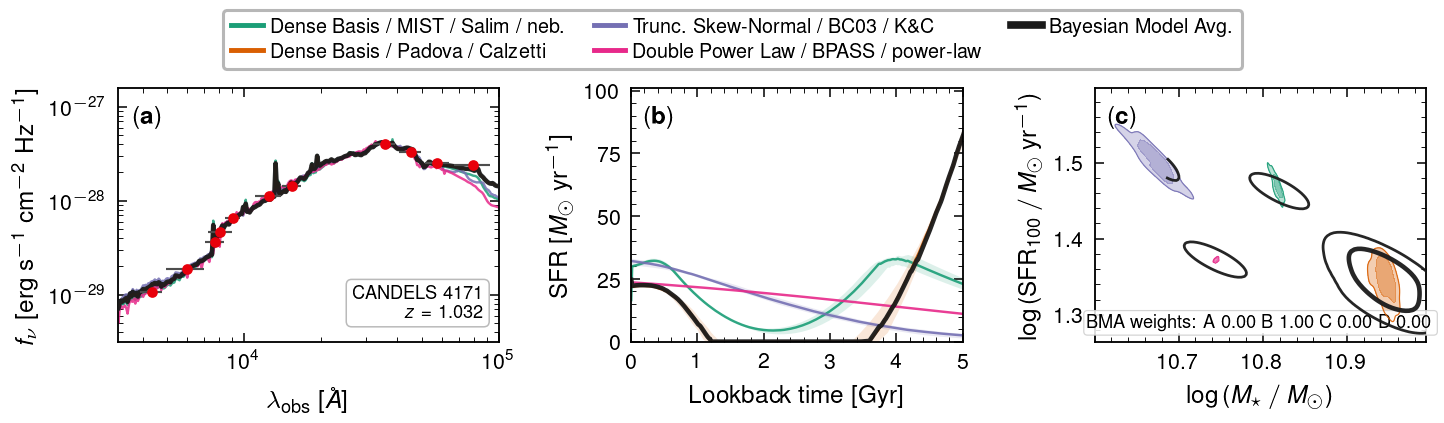

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [11]:
plot_galaxy(4171)

In [12]:
show_timings(4171)

CANDELS 4171  (z = 1.032, 11 bands)
  build (4 models, incl. precompute publish + first compile):   0.3 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     55.1    -326.4
  Dense Basis / Padova / Calzetti     8     64.9    -172.8
  Trunc. Skew-Normal / BC03 / K\&C    8     36.2    -230.4
  Double Power Law / BPASS / power-law  6     14.6    -460.3
  total fit time                           170.8


### CANDELS 17418

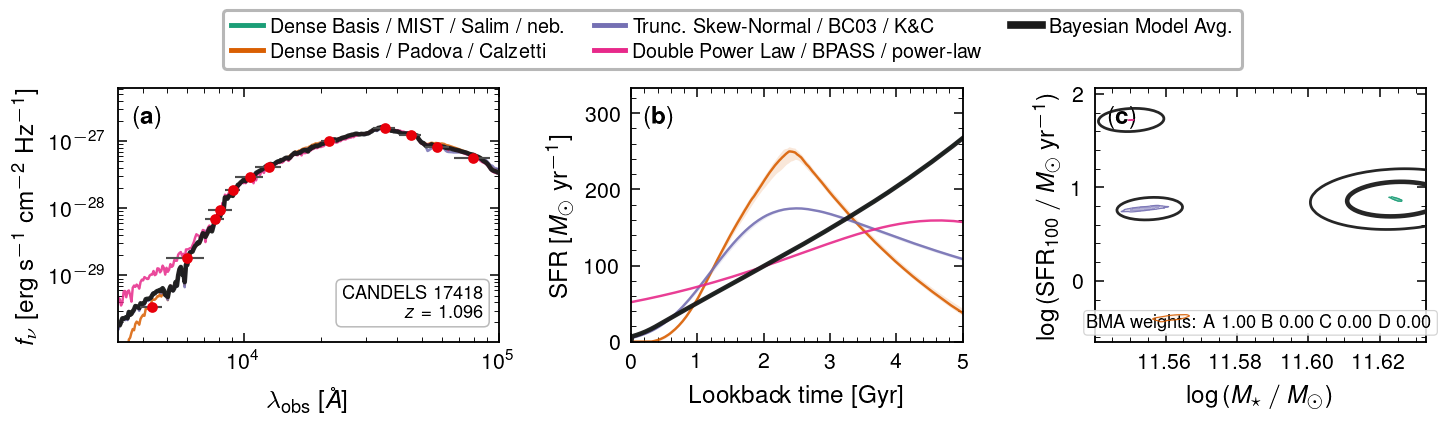

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [13]:
plot_galaxy(17418)

In [14]:
show_timings(17418)

CANDELS 17418  (z = 1.096, 12 bands)
  build (4 models, incl. precompute publish + first compile):   0.3 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     46.3   -2266.4
  Dense Basis / Padova / Calzetti     8     60.3   -2972.0
  Trunc. Skew-Normal / BC03 / K\&C    8     45.4   -3441.0
  Double Power Law / BPASS / power-law  6     18.9  -14631.7
  total fit time                           170.9


### CANDELS 16435

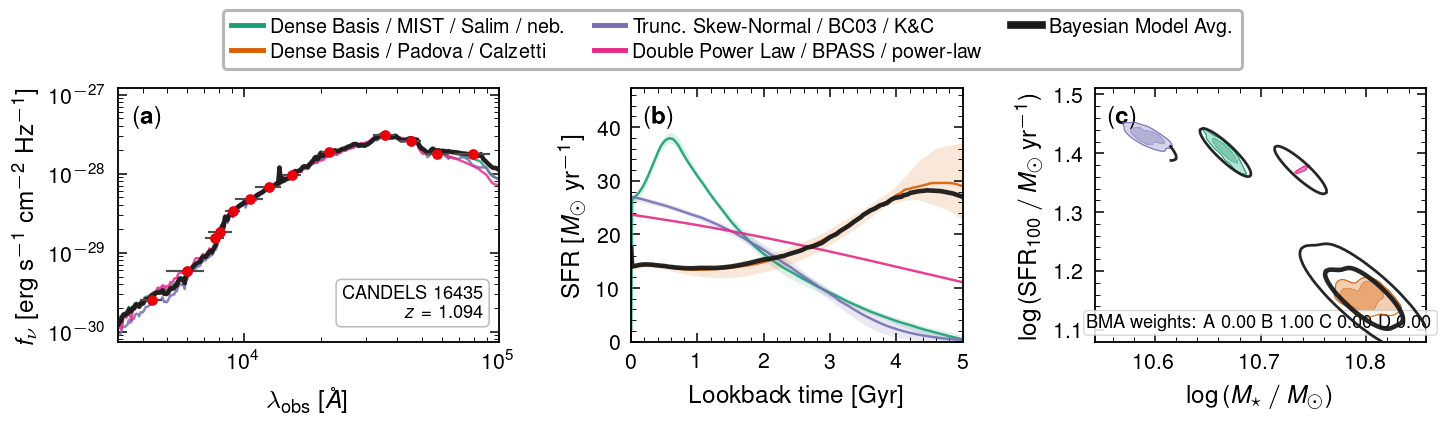

CANDELS 16435: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [15]:
plot_galaxy(16435)

In [16]:
show_timings(16435)

CANDELS 16435  (z = 1.094, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.3 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     32.9    -250.9
  Dense Basis / Padova / Calzetti     8     38.3    -176.2
  Trunc. Skew-Normal / BC03 / K\&C    8     39.3    -539.8
  Double Power Law / BPASS / power-law  6     14.1    -539.1
  total fit time                           124.6


### CANDELS 16514

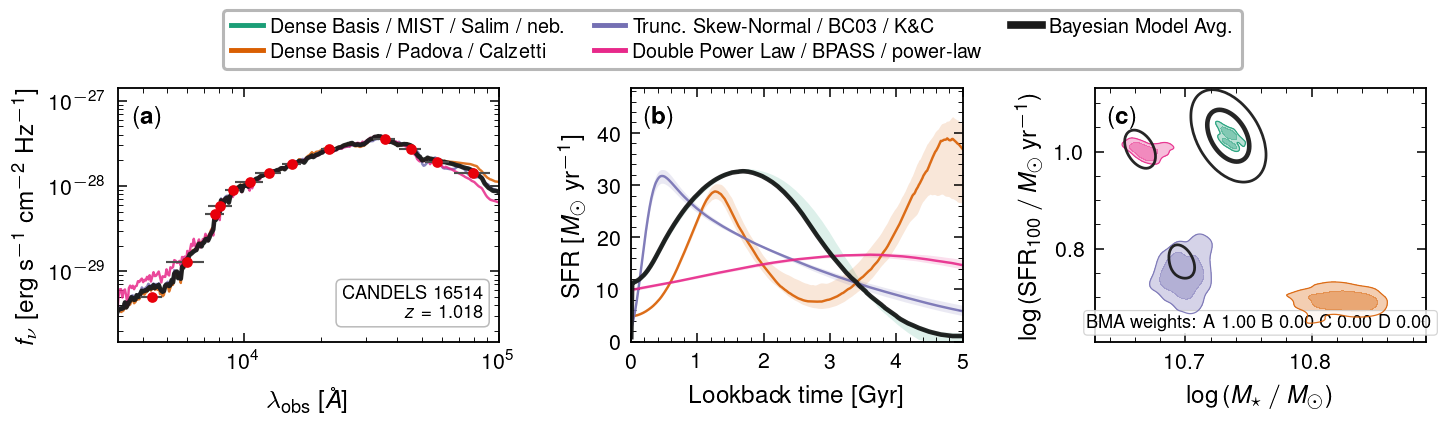

CANDELS 16514: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


In [17]:
plot_galaxy(16514)

In [18]:
show_timings(16514)

CANDELS 16514  (z = 1.018, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.3 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     33.8    -245.3
  Dense Basis / Padova / Calzetti     8     52.1    -258.1
  Trunc. Skew-Normal / BC03 / K\&C    8     39.4    -290.7
  Double Power Law / BPASS / power-law  6     14.1    -809.2
  total fit time                           139.4


### CANDELS 18160

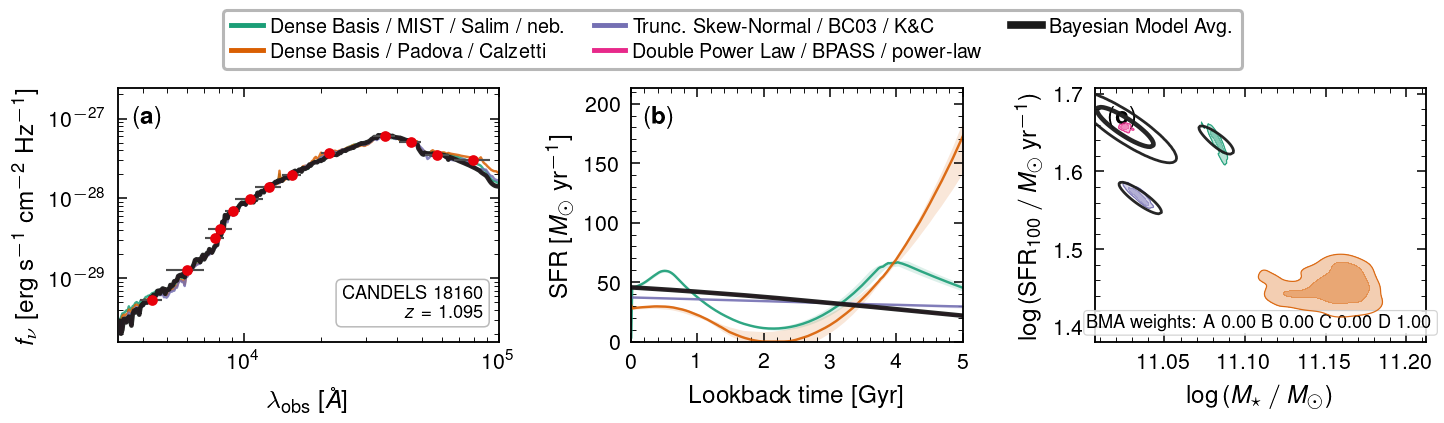

CANDELS 18160: BMA weights  A=0.00  B=0.00  C=0.00  D=1.00


In [19]:
plot_galaxy(18160)

In [20]:
show_timings(18160)

CANDELS 18160  (z = 1.095, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.3 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     46.2    -442.5
  Dense Basis / Padova / Calzetti     8     67.1    -624.1
  Trunc. Skew-Normal / BC03 / K\&C    8     36.7    -756.8
  Double Power Law / BPASS / power-law  6     14.4    -341.7
  total fit time                           164.4


### CANDELS 15775

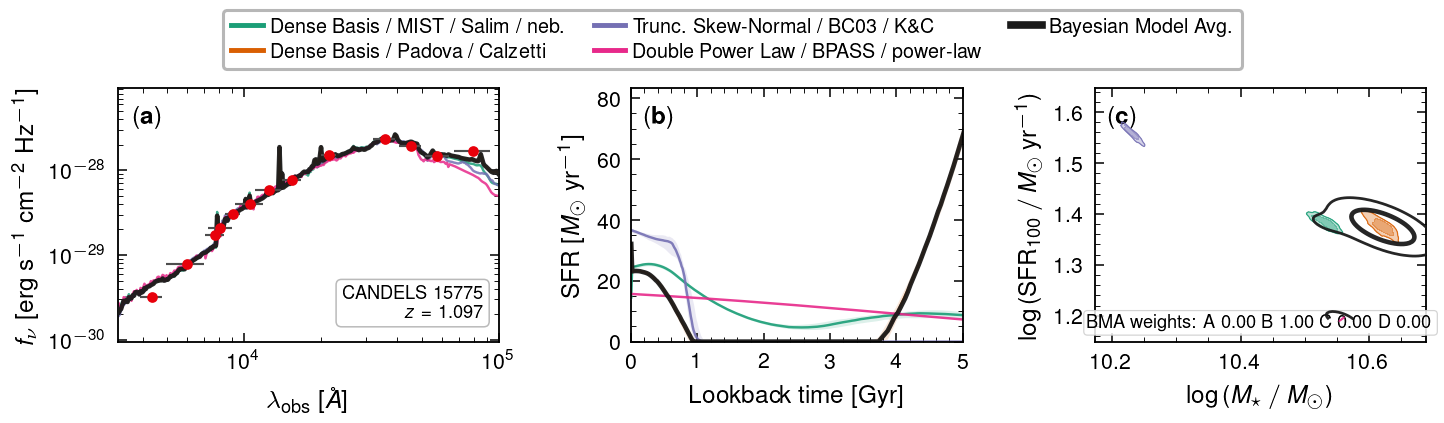

CANDELS 15775: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [21]:
plot_galaxy(15775)

In [22]:
show_timings(15775)

CANDELS 15775  (z = 1.097, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.4 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     54.5    -645.6
  Dense Basis / Padova / Calzetti     8     65.3    -434.4
  Trunc. Skew-Normal / BC03 / K\&C    8     44.5   -1568.5
  Double Power Law / BPASS / power-law  6     15.9   -1965.6
  total fit time                           180.3


### CANDELS 13097

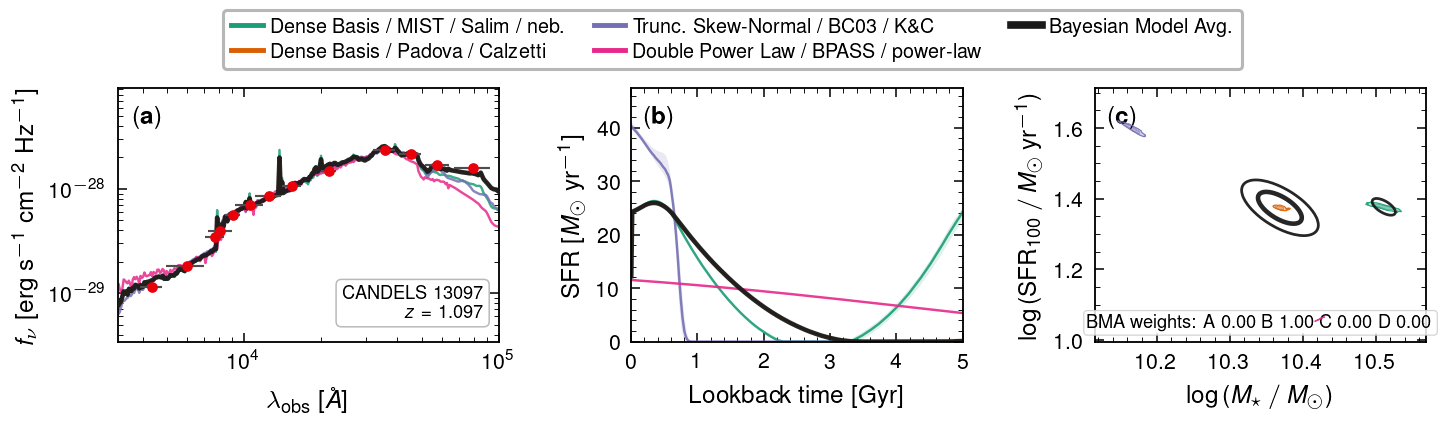

CANDELS 13097: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [23]:
plot_galaxy(13097)

In [24]:
show_timings(13097)

CANDELS 13097  (z = 1.097, 13 bands)
  build (4 models, incl. precompute publish + first compile):   0.3 s
  configuration                       D  fit [s]     log Z
  Dense Basis / MIST / Salim / neb.   8     64.6   -1006.3
  Dense Basis / Padova / Calzetti     8     66.2    -497.5
  Trunc. Skew-Normal / BC03 / K\&C    8     44.7    -728.0
  Double Power Law / BPASS / power-law  6     14.9   -3553.6
  total fit time                           190.4


## 10. Presentation-quality figures

Slide-ready renders of the three panels: larger fonts and panels, thicker
lines, a robust SFH y-limit (so the panel fills), padded $M_\star$–SFR axes,
the BMA shown as an unshaded outline, and the BMA weights annotated on panel
(c). Saved as ``*_pres.png``.

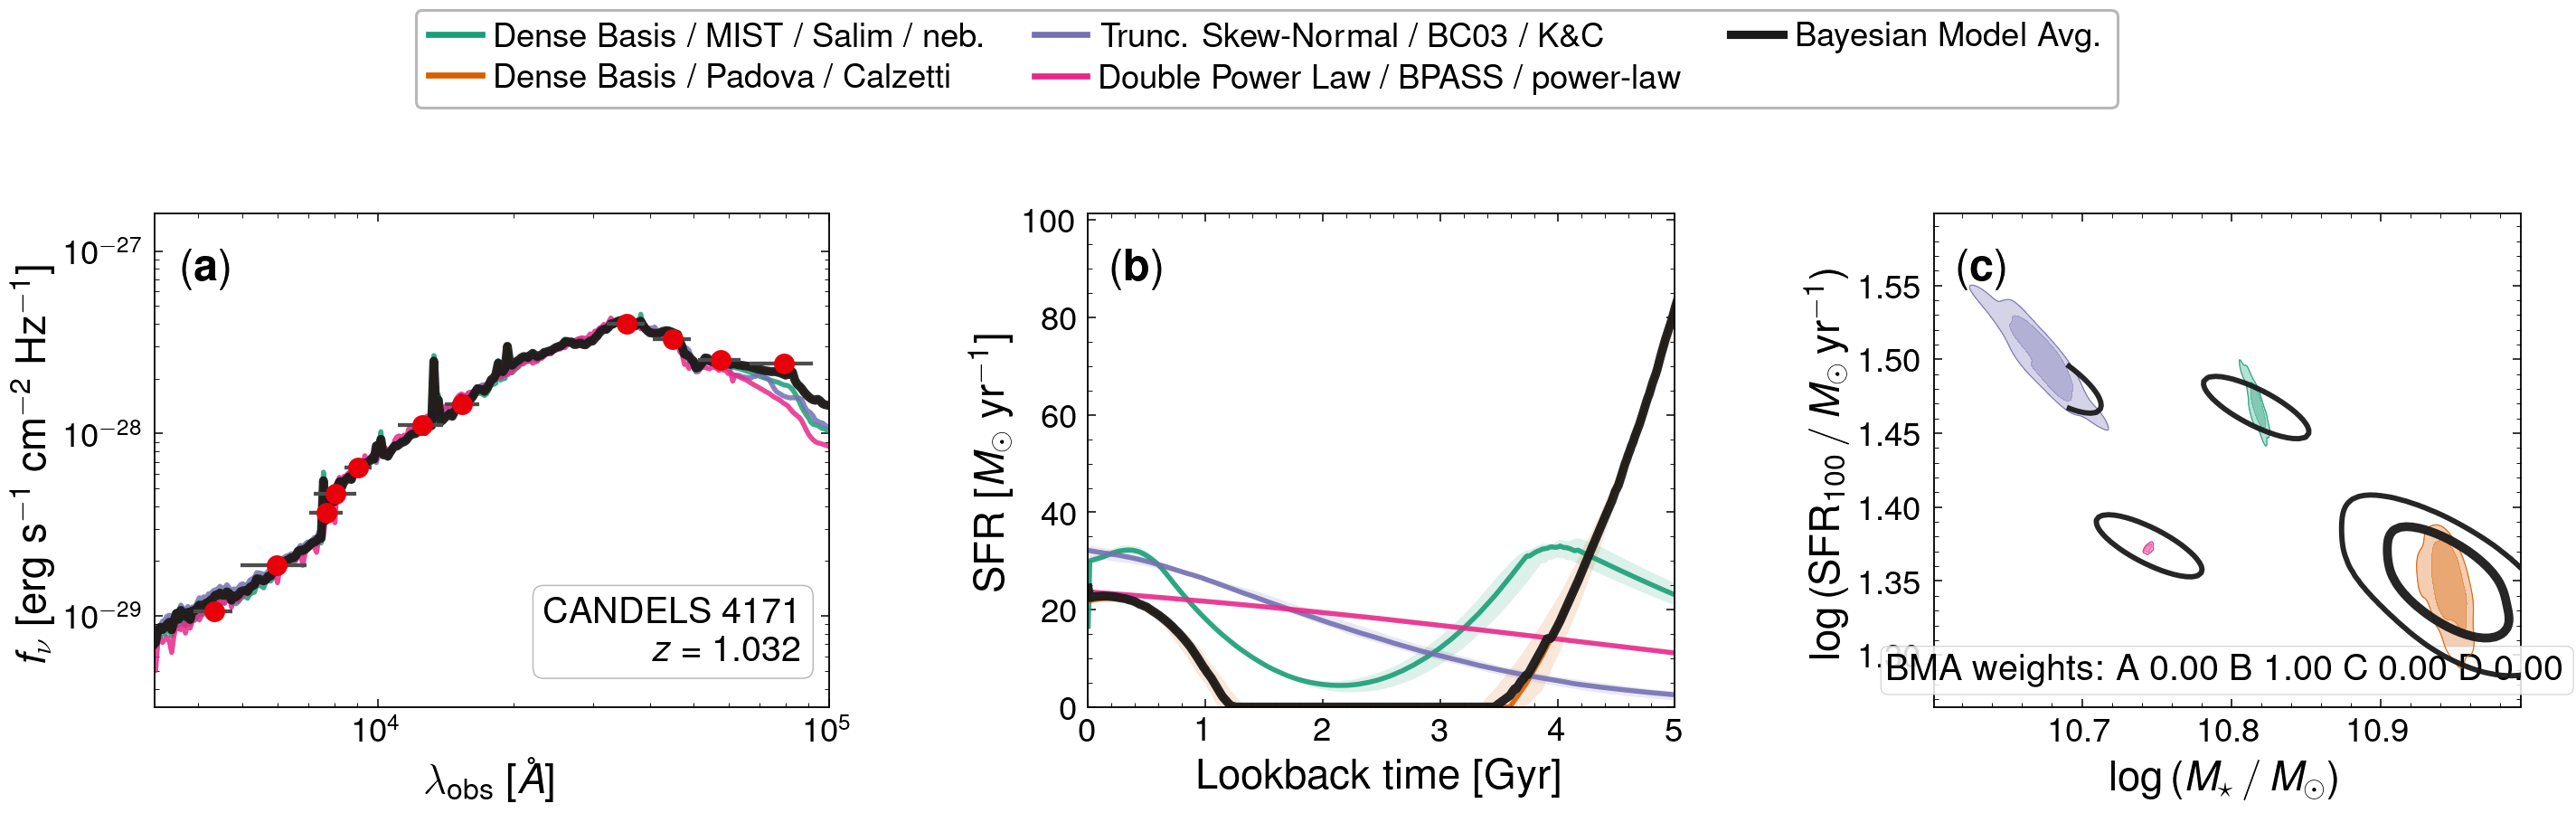

CANDELS 4171: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


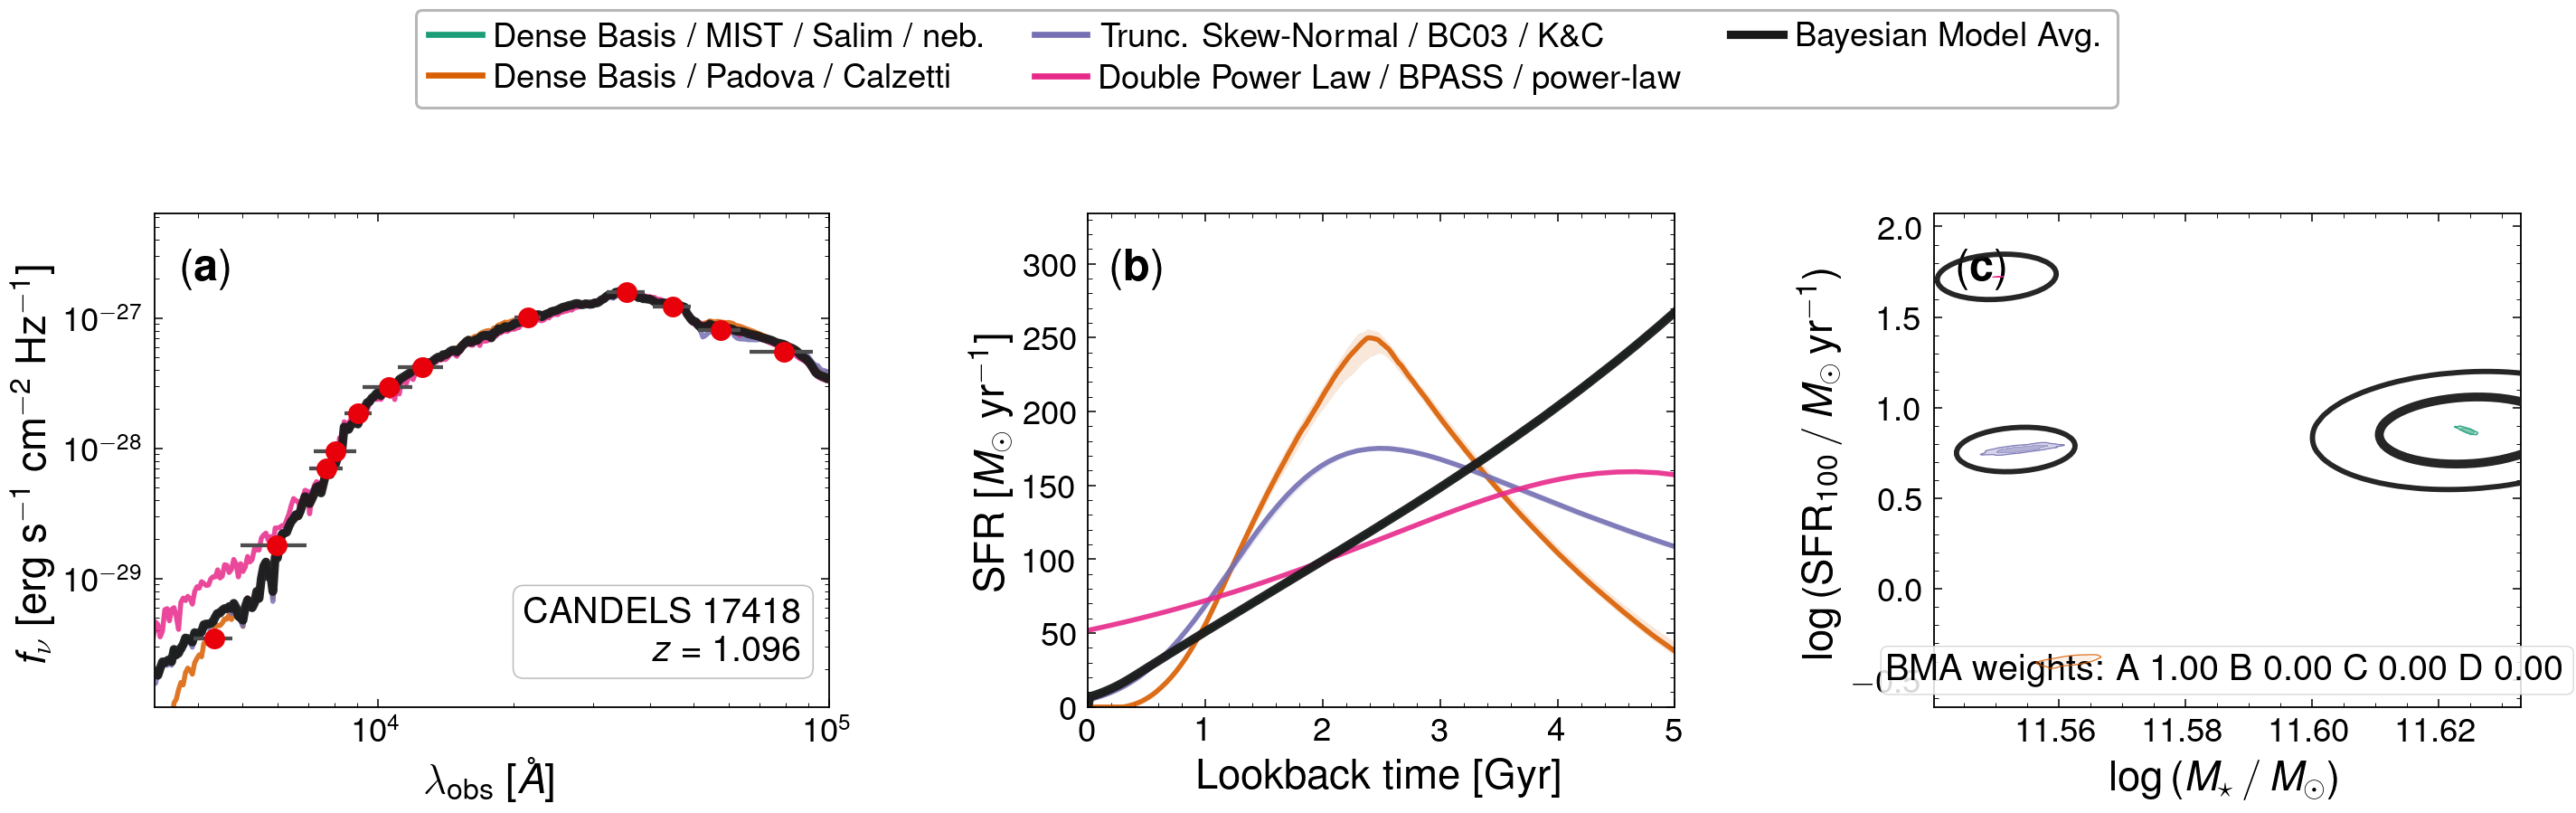

CANDELS 17418: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


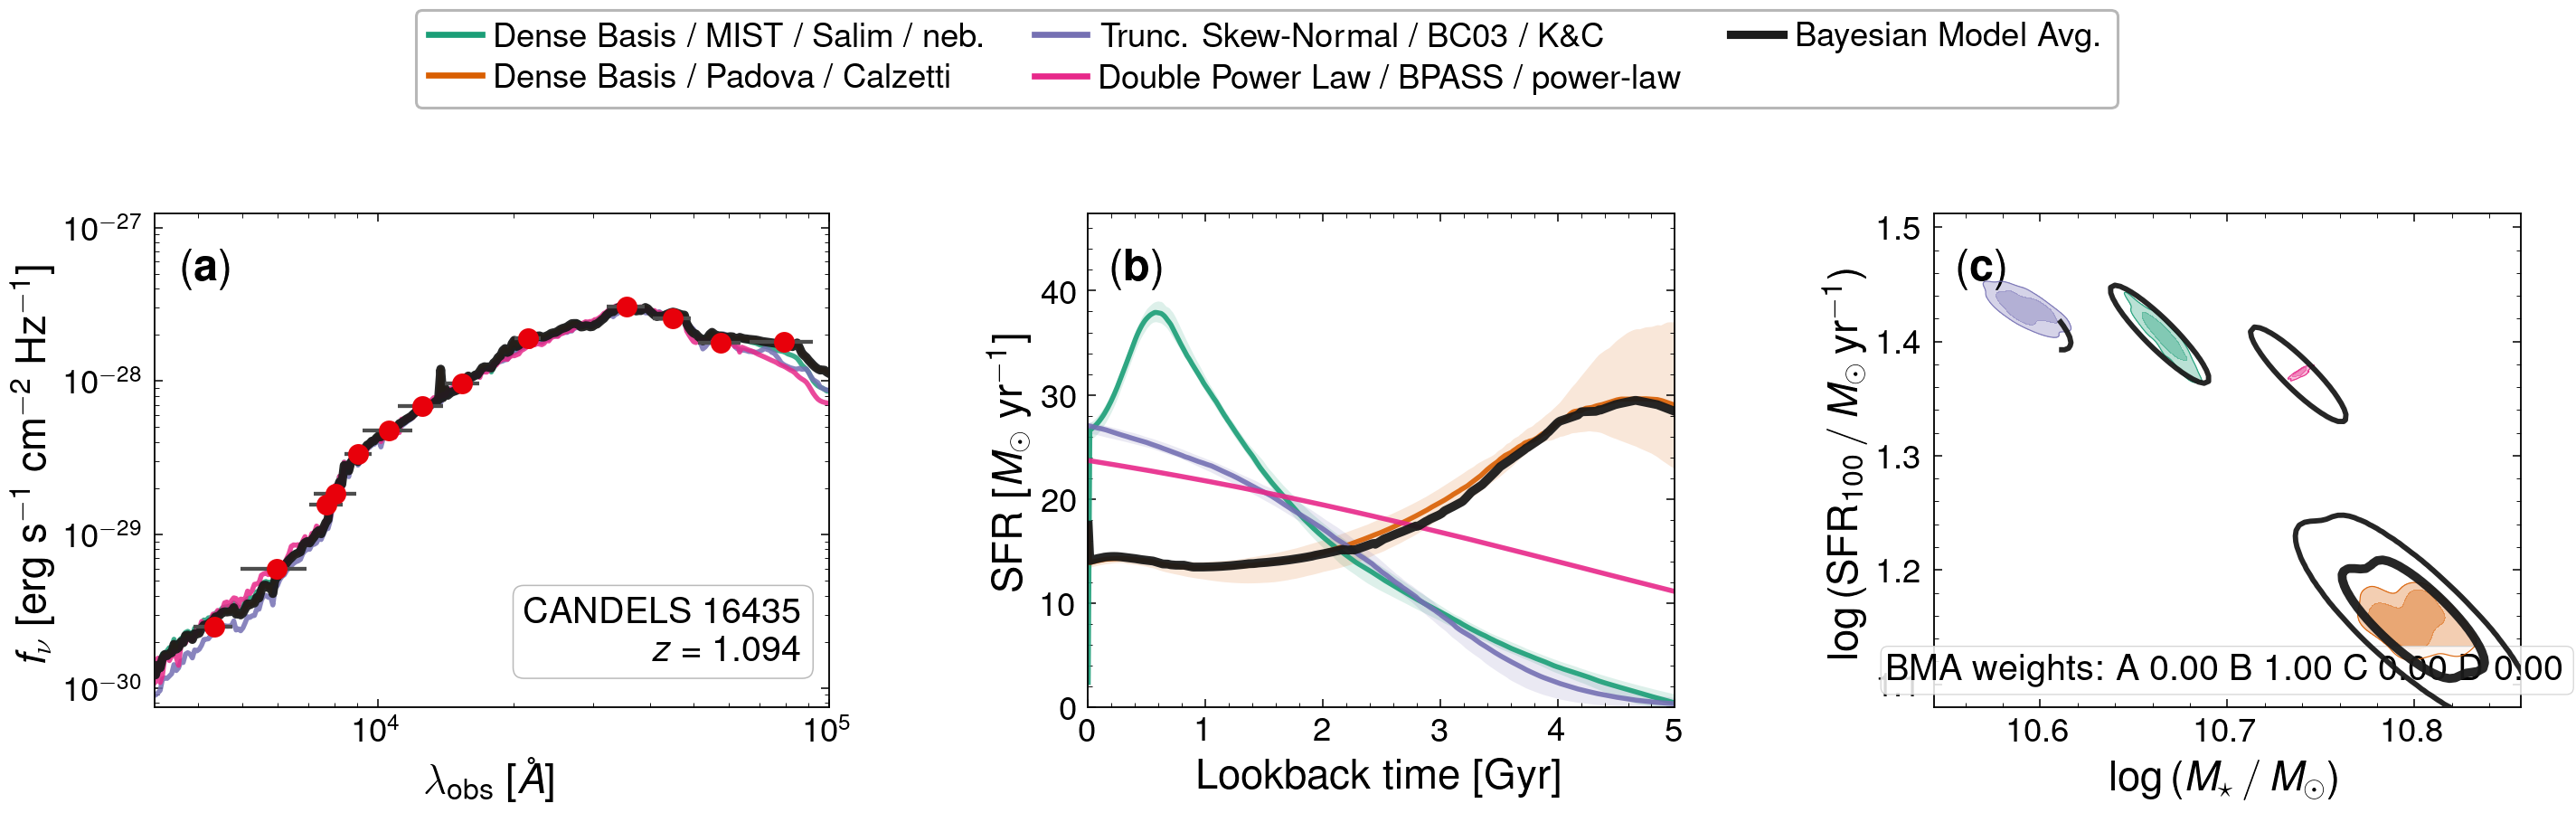

CANDELS 16435: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


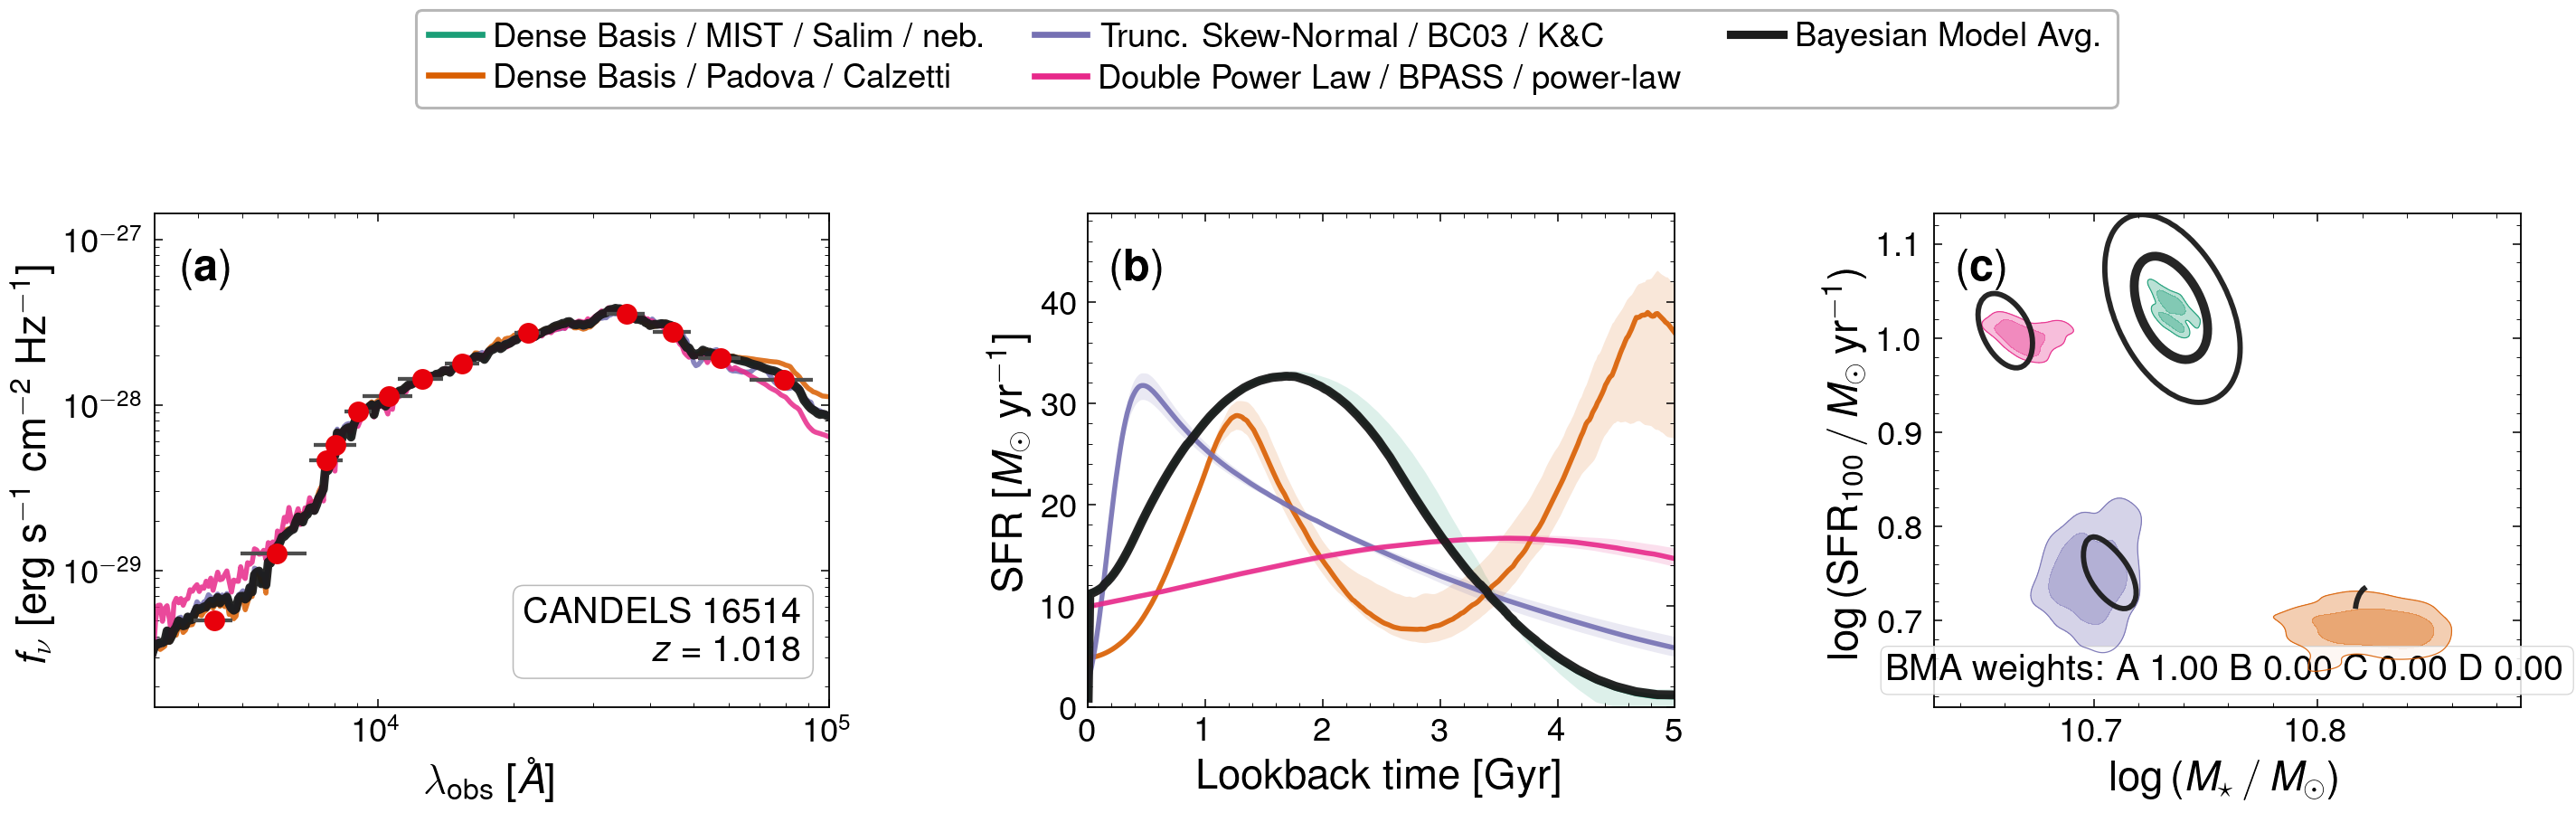

CANDELS 16514: BMA weights  A=1.00  B=0.00  C=0.00  D=0.00


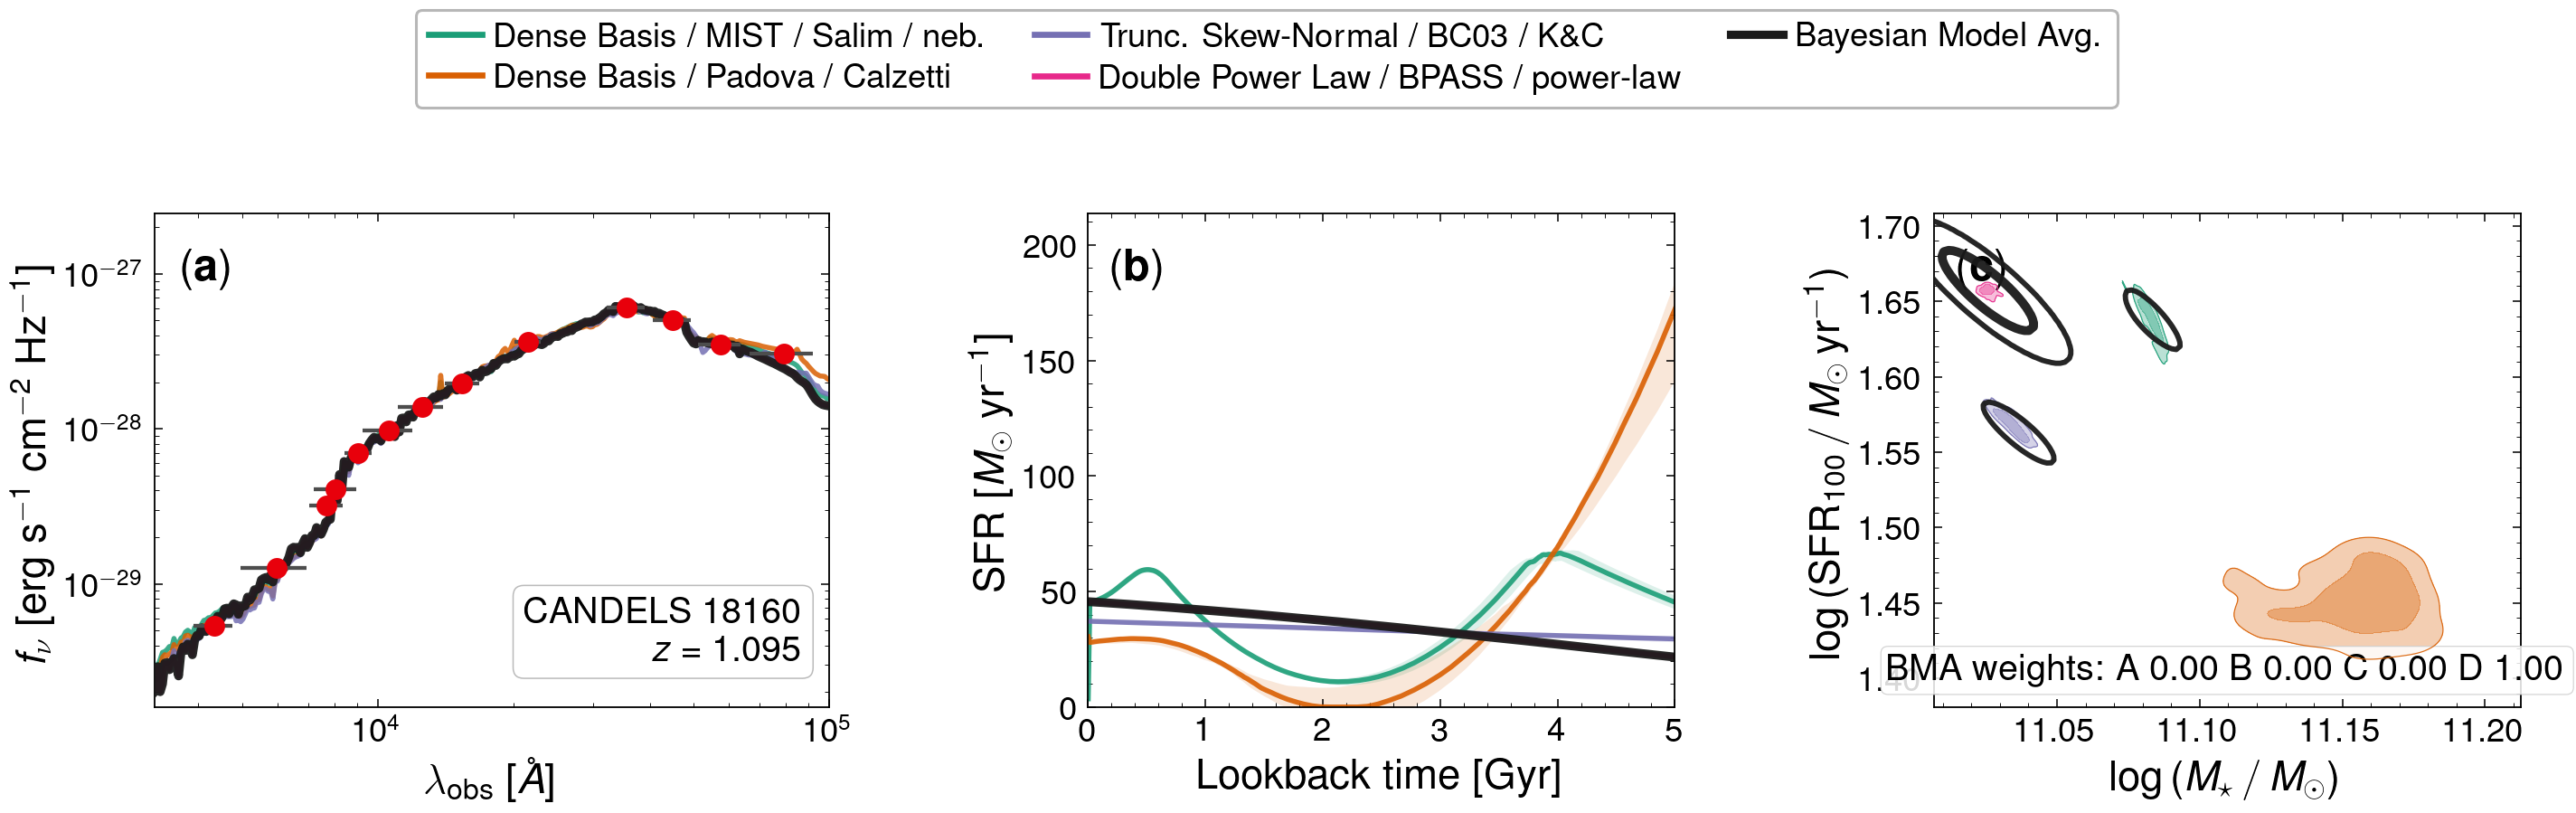

CANDELS 18160: BMA weights  A=0.00  B=0.00  C=0.00  D=1.00


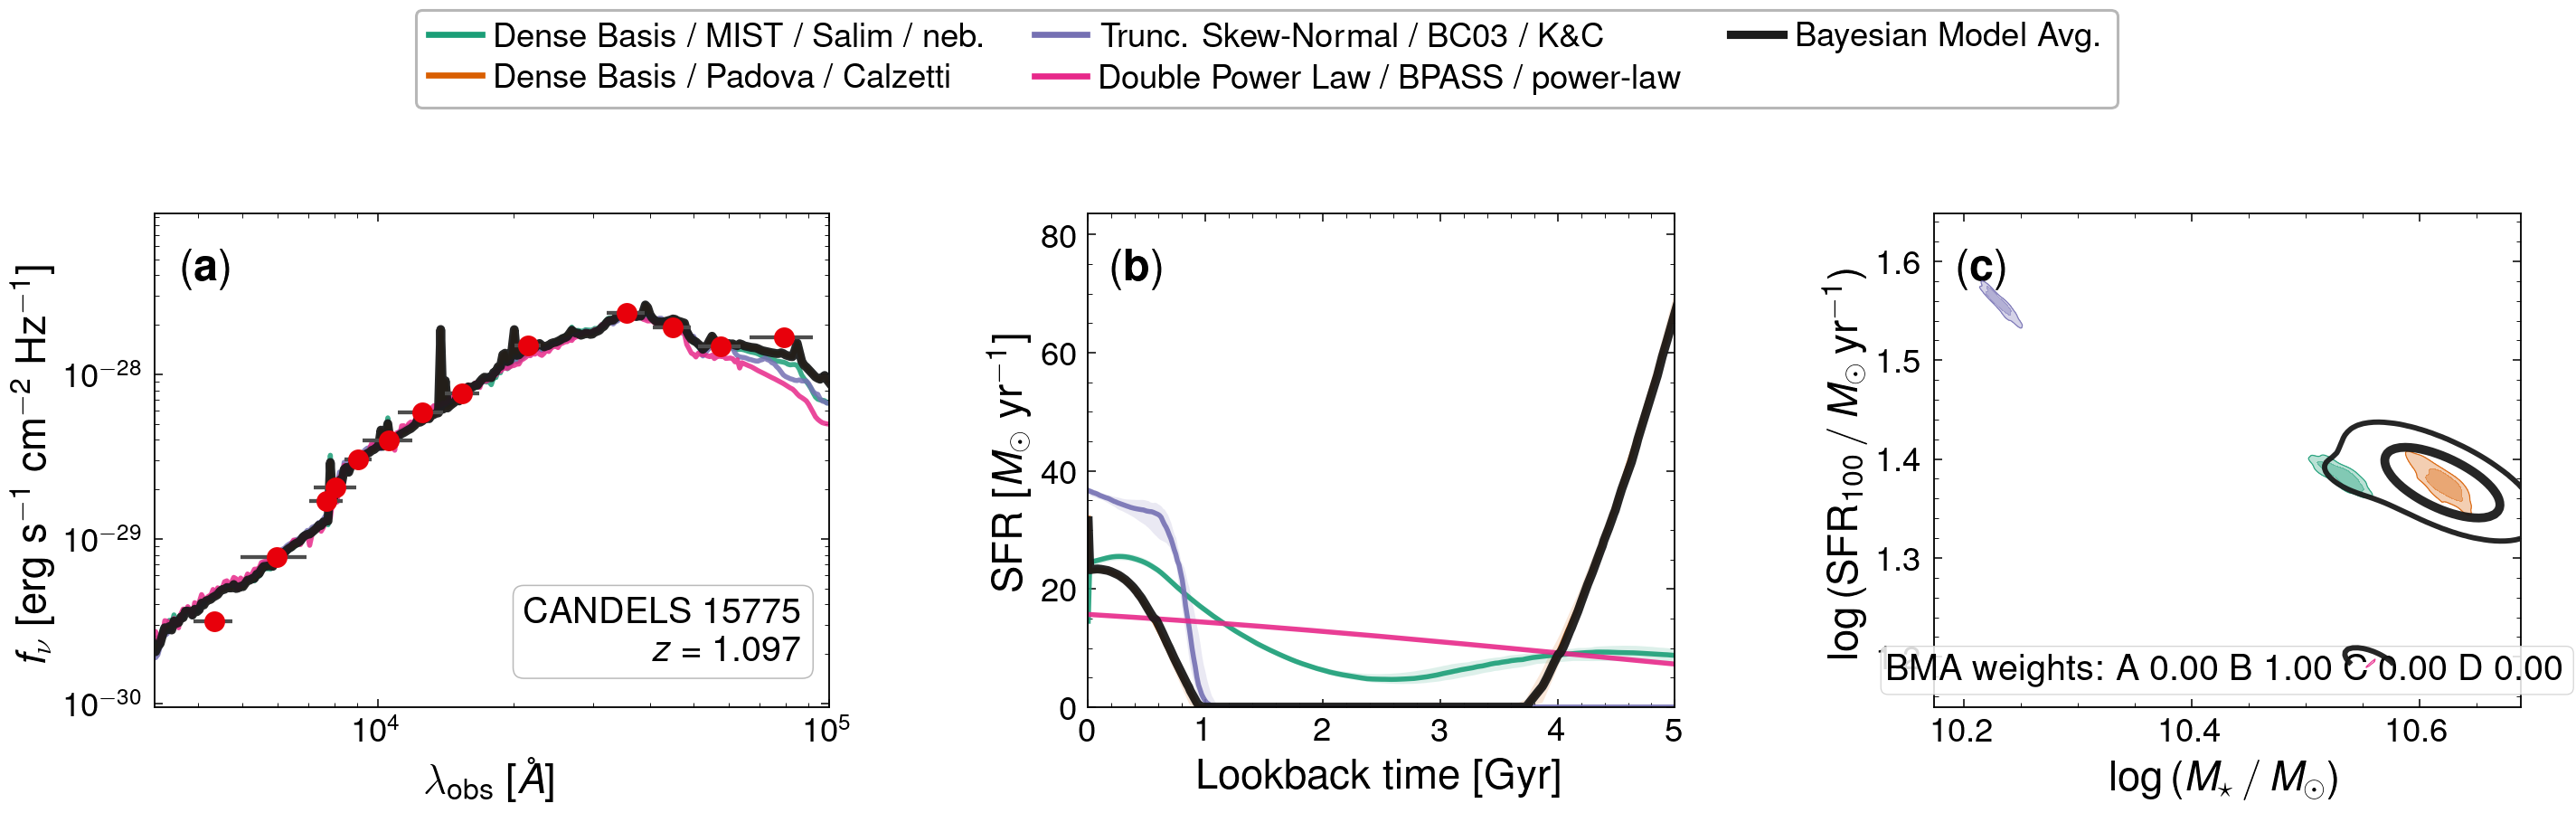

CANDELS 15775: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


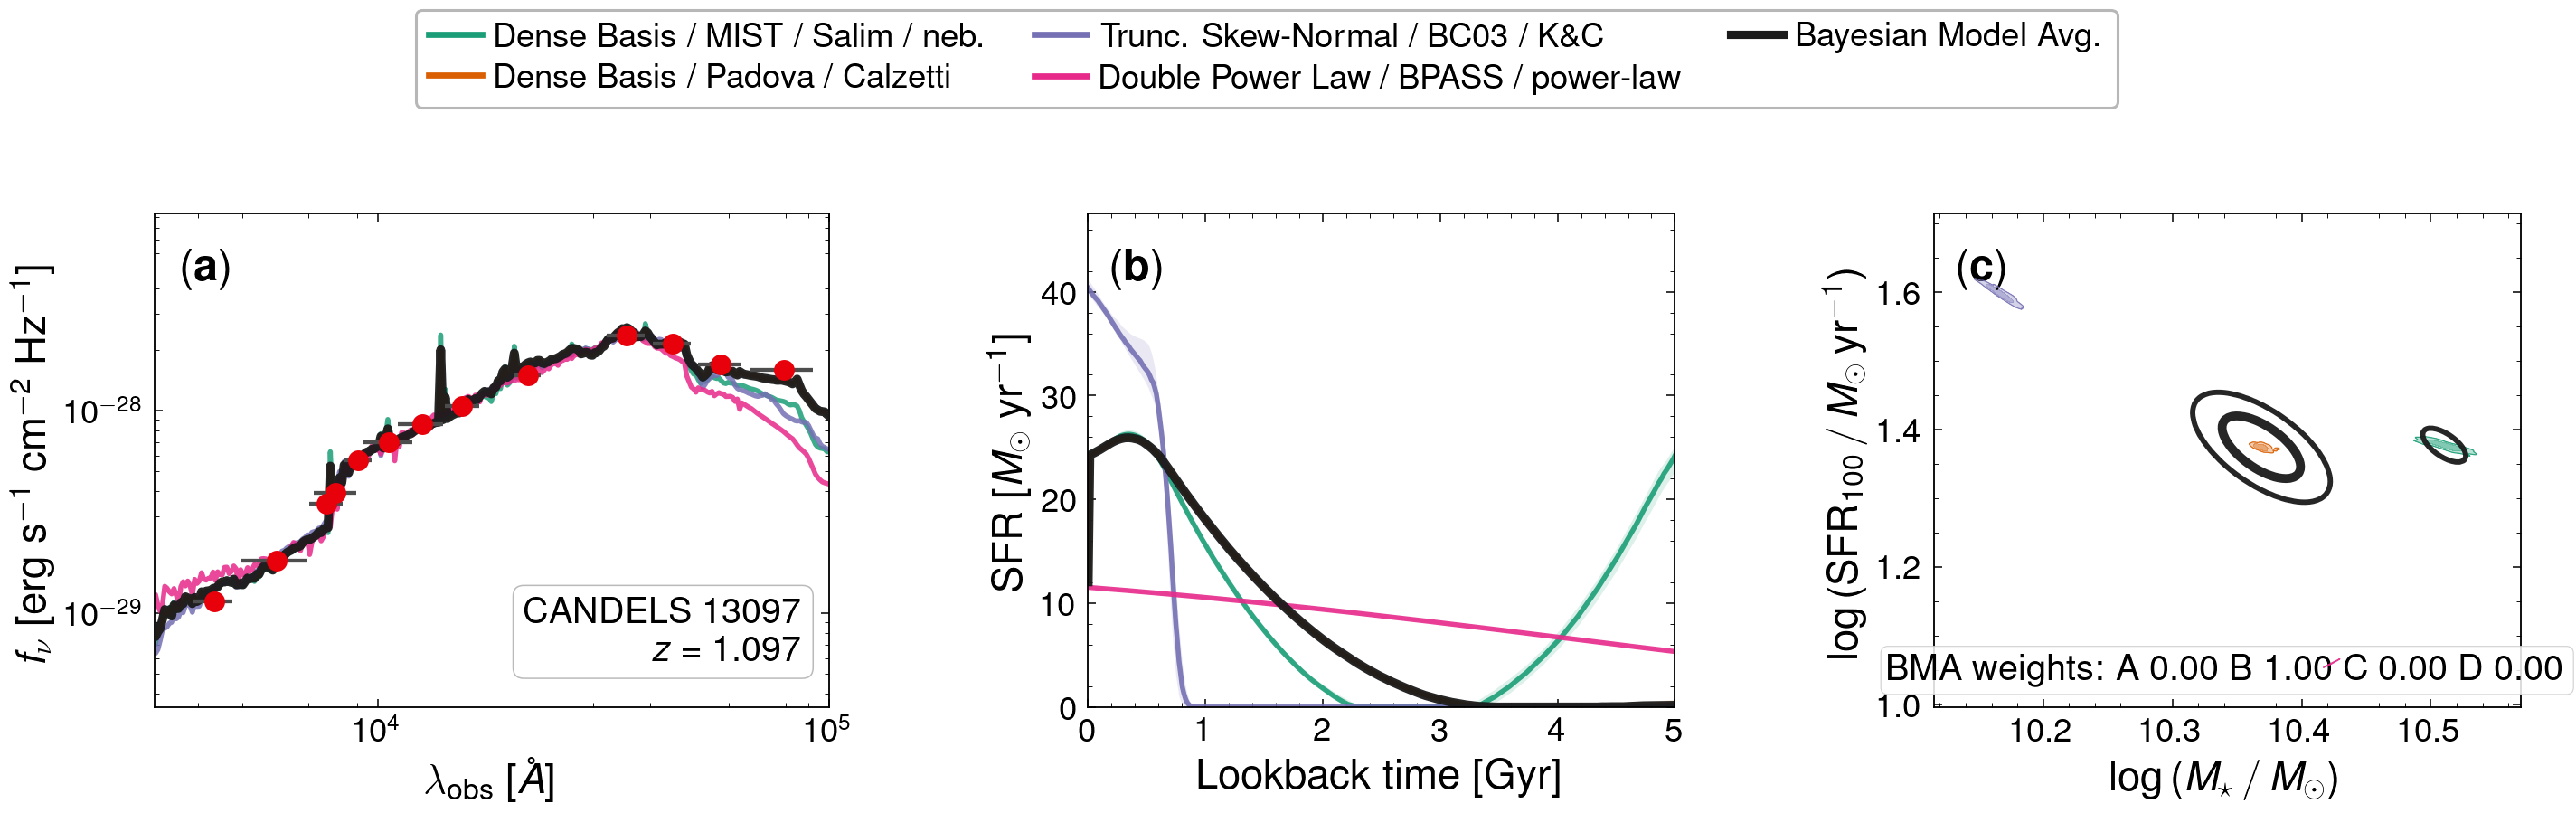

CANDELS 13097: BMA weights  A=0.00  B=1.00  C=0.00  D=0.00


In [25]:
for _gid in GAL_IDS:
    plot_galaxy(_gid, presentation=True)

## 11. Genuine model averaging with an error floor

Every galaxy above collapses onto a single configuration: with the raw
catalogue errors (~1–2% at this S/N) the evidence is overwhelmingly decisive,
so the BMA *is* the single best model. That is honest, but it hides what BMA is
for.

Catalogue errors are **statistical only** — they omit systematics
(zero-points, aperture matching, filter curves) and, crucially for model
comparison, **template imperfection** (the SPS models are good to only a few
percent). Standard practice (EAZY/FAST template-error + ~5% systematic,
Prospector noise inflation, CIGALE per-band floors) is to add a fractional
**error floor in quadrature to the uncertainty that enters the likelihood**,

$$\sigma_\mathrm{eff}^2 = \sigma_\mathrm{cat}^2 + (f_\mathrm{floor}\,f_\nu)^2 .$$

With a 10% floor the per-band $\chi^2$ no longer explodes, the evidences become
commensurable, and the BMA spreads its weight across configurations — genuine
averaging. (The cost is broader, more overlapping $M_\star$–SFR clusters: the
floor trades the artificially tight per-model posteriors for honest ones.)

In [26]:
ERROR_FLOOR = 0.10  # 10% systematic + template-error floor, added in quadrature
FLOOR_IDS = [18160, 17418]  # picked (by a weight-entropy screen) to show real averaging
galaxies_floor = {}
for gal_idx in [int(np.where(ids == g)[0][0]) for g in FLOOR_IDS]:
    gal_id, z, names, fnu, sigma_cat = extract_photometry(gal_idx)
    sigma = jnp.sqrt(sigma_cat**2 + (ERROR_FLOOR * fnu) ** 2)  # inflated uncertainty
    obs = Observation(photometry=Photometry.from_names(names))
    models = build_configs(z, obs)
    posteriors = {}
    for cfg in CONFIG_ORDER:
        key = jax.random.PRNGKey(abs(hash((gal_id, cfg, "floor"))) % (2**31))
        posteriors[cfg] = Fitter(models[cfg], fnu, sigma).run(
            "nss", key=key, n_live=N_LIVE, n_posterior_samples=N_POST, verbose=False
        )
    g = dict(z=z, names=names, fnu=np.asarray(fnu), sigma=np.asarray(sigma),
             models=models, posteriors=posteriors, build_s=0.0,
             fit_timings={c: 0.0 for c in CONFIG_ORDER})  # fmt: skip
    g["weights"] = bma_weights(posteriors)
    g["spec"], g["sfh"], g["props"] = collect_predictions(g)
    galaxies_floor[gal_id] = g
    wstr = "  ".join(f"{c}={x:.2f}" for c, x in zip(CONFIG_ORDER, g["weights"]))
    print(f"CANDELS {gal_id} (floor {ERROR_FLOOR:.0%}):  BMA weights  {wstr}")

W0605 22:20:46.199665 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:46.282947 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:46.286069 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:46.288561 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:46.291144 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:46.314782 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:20:46.441048 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:20:46.960107 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:46.982823 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:46.995734 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.002902 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.009726 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.033915 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.040764 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.047139 3527797 pjrt_executable.cc:638] Assume v

W0605 22:20:47.412834 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.415472 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.418247 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.456634 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.526475 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.530578 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.539536 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:20:47.555231 3527797 pjrt_executable.cc:638] Assume v

W0605 22:20:48.063835 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


...

W0605 22:23:17.569169 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:23:18.178748 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


W0605 22:23:18.422260 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.
W0605 22:23:18.590796 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


CANDELS 17418 (floor 10%):  BMA weights  A=0.53  B=0.30  C=0.17  D=0.00


W0605 22:23:18.873286 3527797 pjrt_executable.cc:638] Assume version compatibility. PjRt-IFRT does not track XLA executable versions.


### CANDELS 18160 — 10% error floor (BMA averages four configurations)

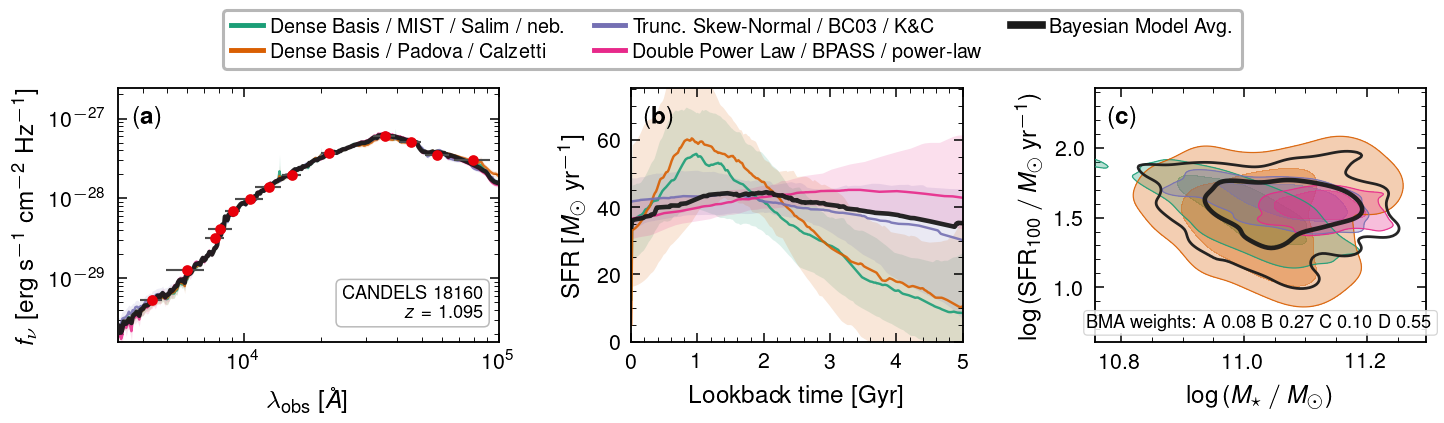

CANDELS 18160: BMA weights  A=0.08  B=0.27  C=0.10  D=0.55


In [27]:
plot_galaxy(18160, source=galaxies_floor, tag="_floor")

### CANDELS 17418 — 10% error floor (BMA averages three configurations)

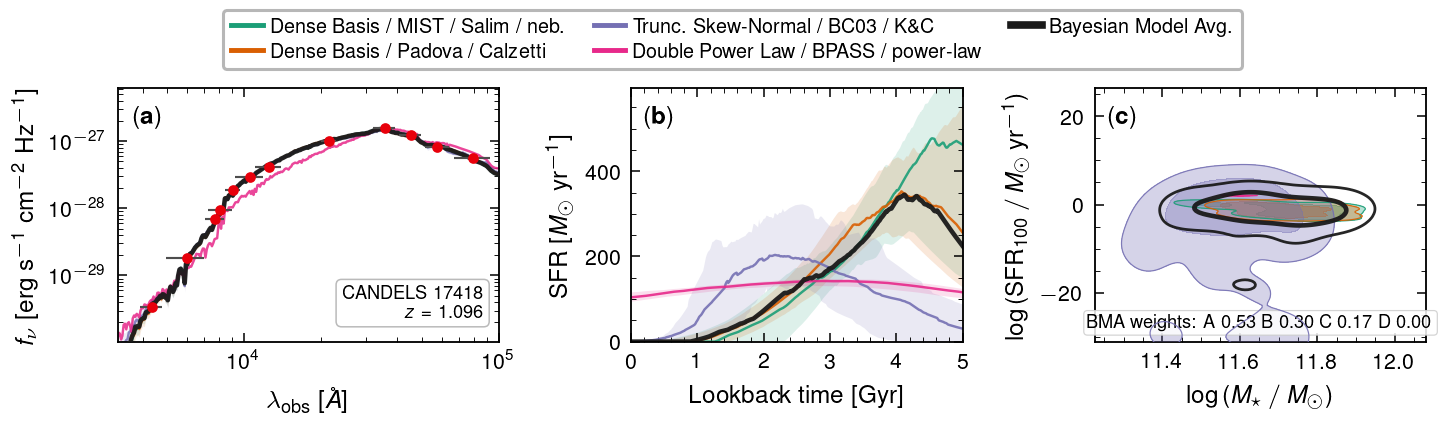

CANDELS 17418: BMA weights  A=0.53  B=0.30  C=0.17  D=0.00


In [28]:
plot_galaxy(17418, source=galaxies_floor, tag="_floor")

## 12. Takeaways

- **The evidence picks favourites.** The BMA weights are rarely uniform — one
  or two configurations usually dominate $\log Z$, and the average is pulled
  toward them while still retaining the others' spread.
- **The models genuinely disagree.** Panel (c) shows four tight but
  *separated* $M_\star$–SFR clusters: swapping SSP library, SFH family, or dust
  law moves the inferred stellar mass by a few tenths of a dex even at fixed
  photometry. That systematic spread is exactly what BMA exposes.
- **Same public surface throughout.** Every model came from
  `SEDModel.build(...)` with the nested-dict grammar; the only knob that
  changed for speed was `approx=WavePrecomp()`. Inference was the one-liner
  `Fitter(model, data, noise).run("nss", ...)`, whose `log_evidence` is what
  makes the averaging principled.
- **The error budget decides whether you average.** With raw catalogue errors
  the evidence collapses onto one model; adding a realistic ~10% systematic
  floor (§11) makes the evidences commensurable and the BMA genuinely averages.
  Whether to average — or to trust the single best model — is set by how well
  you believe your photometry *and templates*, not by the fitter.